# UAV Battery Tool — Notebook 03: Discharge Simulation

**Model:** V_terminal = V_ocv(SoC) - dV_ohmic(T) - dV_ct(T,SoC) - dV_conc(I,SoC)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings; warnings.filterwarnings("ignore")

from batteries.database import BatteryDatabase
from batteries.voltage_model import (
    CHEM_VOLTAGE_PARAMS, arrhenius_scale,
    r_ohmic_mohm, r_ct_mohm, total_pack_resistance_mohm, terminal_voltage,
)
from mission.simulator import run_simulation, compare_batteries, temperature_sweep

plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.grid": True, "grid.alpha": 0.25})
DB_PATH = "../battery_db.xlsx"
db = BatteryDatabase(DB_PATH).load()
print(db.summary())

═══ Battery Database Summary ═══
  Chemistries       : 9
  Cells             : 11
  Battery packs     : 125
  Discharge points  : 132
  Equipment items   : 29
  UAV configurations: 3
  Mission profiles  : 3


In [2]:
# ── Load settings from analysis_config.json (written by 02_configurator) ──────
import json as _json, os as _os
# Look for analysis_config.json: try ../  (notebooks/ CWD) then ./  (root CWD)
for _p in ['../analysis_config.json', 'analysis_config.json']:
    if _os.path.exists(_p):
        _CFG_PATH = _p
        break
else:
    _CFG_PATH = '../analysis_config.json'  # default write-path
_cfg = {}
if _os.path.exists(_CFG_PATH):
    with open(_CFG_PATH) as _f:
        _cfg = _json.load(_f)
    print(f'Loaded config from {_CFG_PATH}')
else:
    print('No analysis_config.json found — using defaults (run 02_configurator first)')

# ── Mission / UAV / temperature settings ──────────────────────────────────────
SIM_MISSION_ID = _cfg.get('mission_id',     'SURVEY_STD')
SIM_UAV_ID     = _cfg.get('uav_id',         'HEX_SURVEY_900')
AMBIENT_TEMP_C = _cfg.get('ambient_temp_c', 25.0)
TEMP_SWEEP     = _cfg.get('temp_sweep',     [-25, -10, 0, 15, 25, 40])

# ── Selected batteries (all of them) ──────────────────────────────────────────
_sel = _cfg.get('selected_batteries', ['BAT_MID_6S2P'])
selected_pack_ids = _sel if isinstance(_sel, list) else ['BAT_MID_6S2P']
COMPARE_PACK_IDS  = selected_pack_ids   # alias used by Section 5

# Filter to IDs that exist in the database
selected_pack_ids = [pid for pid in selected_pack_ids if pid in db.packs]
if not selected_pack_ids:
    selected_pack_ids = list(db.packs.keys())[:3]
    print(f'WARNING: no valid IDs from config — falling back to first 3 packs')

# ── Reconstruct combined pack if configured ────────────────────────────────────
_combo_cfg = _cfg.get('battery_combination')
if _combo_cfg:
    from batteries.builder import combine_packs as _combine_packs
    _combo_packs = [db.packs[bid] for bid in _combo_cfg.get('packs', []) if bid in db.packs]
    if len(_combo_packs) >= 2:
        _combined = _combine_packs(_combo_packs, topology=_combo_cfg.get('topology', 'series'))
        db.packs[_combined.battery_id] = _combined
        print(f'Combined pack registered: {_combined.battery_id}')

# ── Manual overrides ──────────────────────────────────────────────────────────
# selected_pack_ids = ['BAT_MID_6S2P', 'BAT_MID_6S4P']   # override selection
# AMBIENT_TEMP_C = 25.0

# ── Shared mission / UAV objects ──────────────────────────────────────────────
mission = db.missions[SIM_MISSION_ID]
uav     = db.uav_configs[SIM_UAV_ID]

# ── Run simulation for every selected battery ─────────────────────────────────
print(f'\nRunning simulation for {len(selected_pack_ids)} pack(s) '
      f'on mission "{SIM_MISSION_ID}" @ {AMBIENT_TEMP_C}\u00b0C ...')

all_results = {}
for _pid in selected_pack_ids:
    _pack = db.packs[_pid]
    all_results[_pid] = run_simulation(
        pack=_pack, mission=mission, uav=uav,
        discharge_pts=db.discharge_pts, initial_soc_pct=100.0,
        ambient_temp_c=AMBIENT_TEMP_C, peukert_k=1.05, dt_s=1.0)
    print(f'  {_pid[:50]:<50}  {all_results[_pid].summary().splitlines()[0]}')

# Keep first-pack aliases for cells that reference them directly
pack   = db.packs[selected_pack_ids[0]]
result = all_results[selected_pack_ids[0]]

Loaded config from analysis_config.json

Running simulation for 6 pack(s) on mission "SURVEY_STD" @ 25.0°C ...
  BAT_LE_12S2P                                        ════════════════════════════════════════════════════
  GREPOW_TATTU_12S_LIPO_DRONE_BATTERY                 ════════════════════════════════════════════════════
  GREPOW_TATTU_12S_10000MAH_44_4V_30C_LIPO_BATTERY    ════════════════════════════════════════════════════
  TATTU_TATTU_PLUS_1_0_COMPACT_VERSION_10000MAH_44_4  ════════════════════════════════════════════════════
  GREPOW_TATTU_PLUS_1_0_12S_10000MAH_44_4V_15C_LIPO_  ════════════════════════════════════════════════════
  TATTU_TATTU_SEMI_SOLID_STATE_330WH_KG_25000MAH_10C  ════════════════════════════════════════════════════


## 1 · Chemistry Resistance vs Temperature

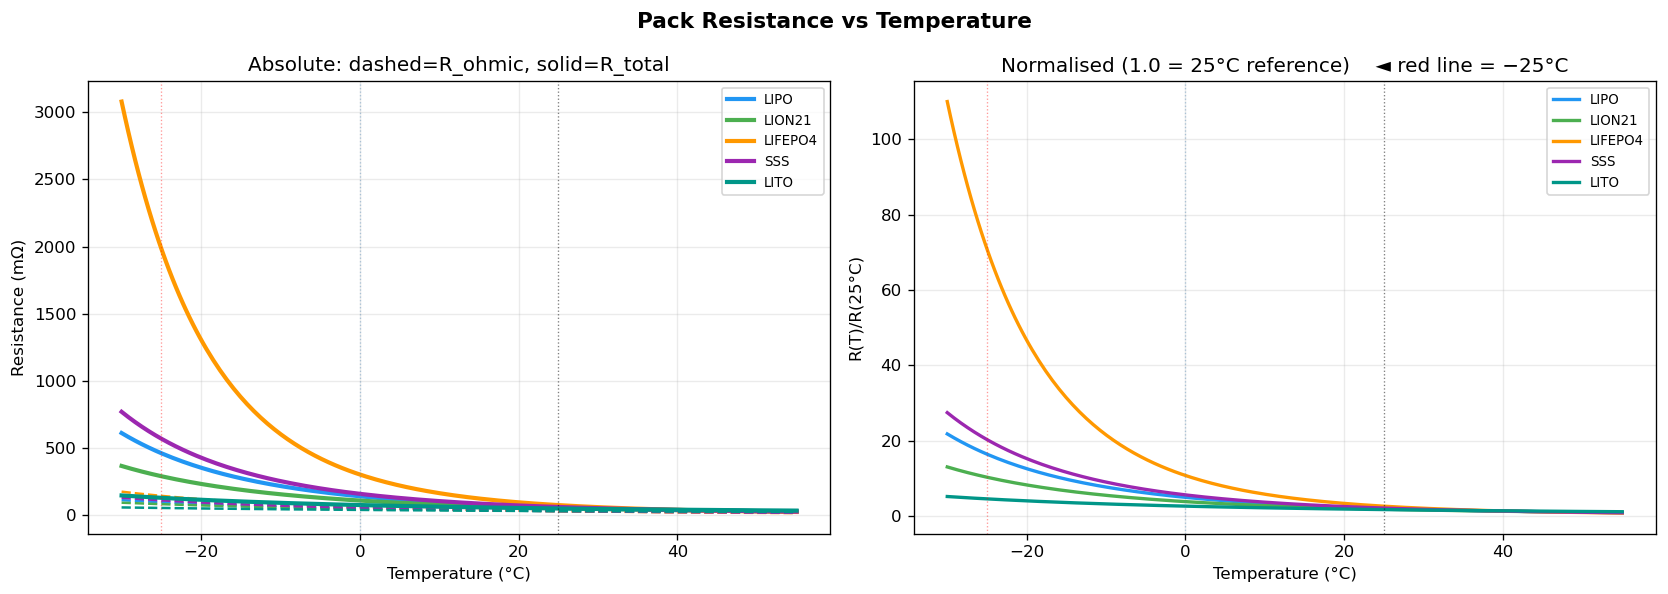


Resistance multiplier vs temperature (relative to 25°C):
Temp (°C)    -25    -15    -5      0     15   25    40
Chemistry                                             
LIFEPO4    70.88  31.37  15.06  10.75  4.36  2.6  1.34
LION21     10.29   6.68   4.55   3.81  2.37  1.8  1.25
LIPO       16.42   9.75   6.13   4.95  2.79  2.0  1.29
LITO        4.54   3.58   2.88   2.61  1.99  1.7  1.37
SSS        20.28  11.62   7.05   5.60  3.01  2.1  1.30

Note: multipliers >1 are physical — cold electrolyte raises both ohmic and
      charge-transfer resistance via Arrhenius kinetics.
      High values (e.g. 10x at -25°C for LIFEPO4) mean the pack will trigger
      its voltage-cutoff BMS protection before SoC reaches zero.


In [3]:
temps = np.linspace(-30, 55, 200)
chemistries = ["LIPO", "LION21", "LIFEPO4", "SSS", "LITO"]
R_REF = 28.0
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pack Resistance vs Temperature", fontsize=13, fontweight="bold")
colors = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#009688"]
for chem, color in zip(chemistries, colors):
    r_ohm = [r_ohmic_mohm(R_REF, chem, t) for t in temps]
    r_ct  = [r_ct_mohm(R_REF, chem, t, 80) for t in temps]
    r_tot = [ro+rc for ro,rc in zip(r_ohm,r_ct)]
    axes[0].plot(temps, r_ohm, color=color, linewidth=1.5, linestyle="--")
    axes[0].plot(temps, r_tot, color=color, linewidth=2.5, label=chem)
    axes[1].plot(temps, [r/R_REF for r in r_tot], color=color, linewidth=2, label=chem)
for ax in axes:
    ax.axvline(25,  color="black",    linewidth=0.8, linestyle=":", alpha=0.5)
    ax.axvline(0,   color="steelblue", linewidth=0.8, linestyle=":", alpha=0.4)
    ax.axvline(-25, color="red",       linewidth=0.8, linestyle=":", alpha=0.4)
axes[0].set_xlabel("Temperature (°C)"); axes[0].set_ylabel("Resistance (mΩ)")
axes[0].set_title("Absolute: dashed=R_ohmic, solid=R_total"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("Temperature (°C)"); axes[1].set_ylabel("R(T)/R(25°C)")
axes[1].set_title("Normalised (1.0 = 25°C reference)    ◄ red line = −25°C")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig("resistance_vs_temperature.png", bbox_inches="tight"); plt.show()

rows = []
for chem in chemistries:
    for t in [-25,-15,-5,0,15,25,40]:
        r = total_pack_resistance_mohm(R_REF, chem, t, 80)
        rows.append({"Chemistry":chem,"Temp (°C)":t,"Multiplier":round(r/R_REF,2)})
tbl = pd.DataFrame(rows).pivot_table(index="Chemistry", columns="Temp (°C)", values="Multiplier")
print("\nResistance multiplier vs temperature (relative to 25°C):")
print(tbl.to_string())
print("\nNote: multipliers >1 are physical — cold electrolyte raises both ohmic and")
print("      charge-transfer resistance via Arrhenius kinetics.")
print("      High values (e.g. 10x at -25°C for LIFEPO4) mean the pack will trigger")
print("      its voltage-cutoff BMS protection before SoC reaches zero.")

## 2 · Voltage Sag Anatomy

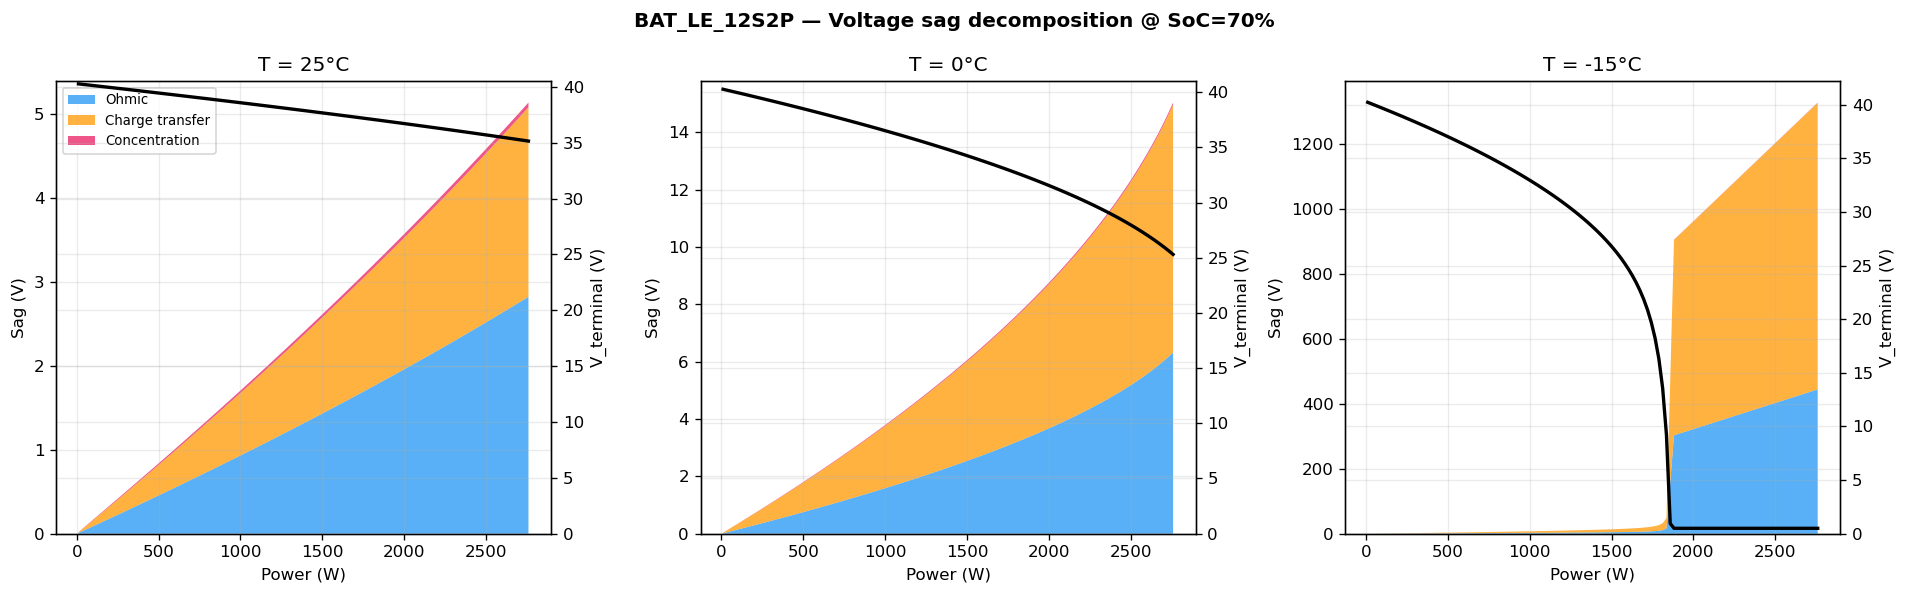

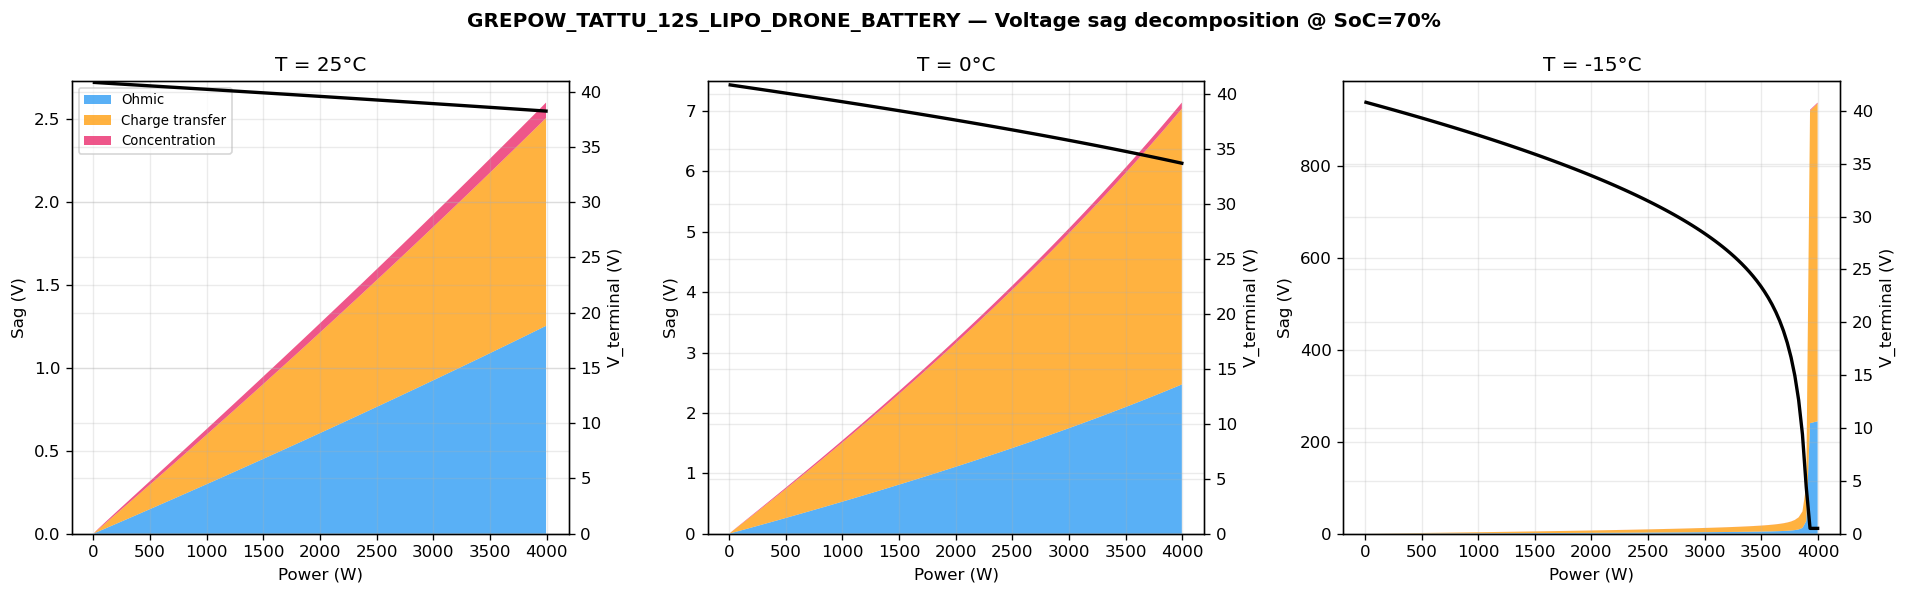

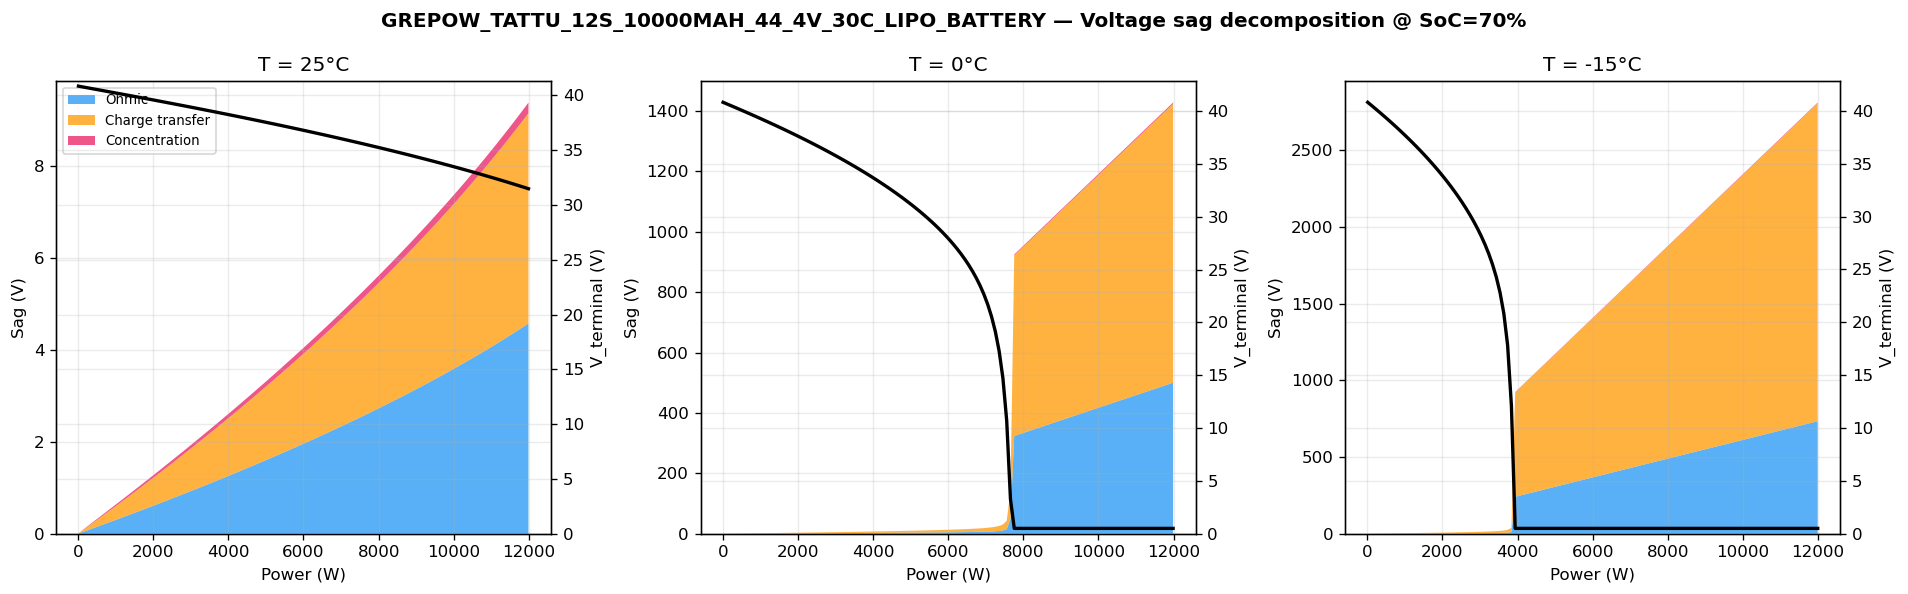

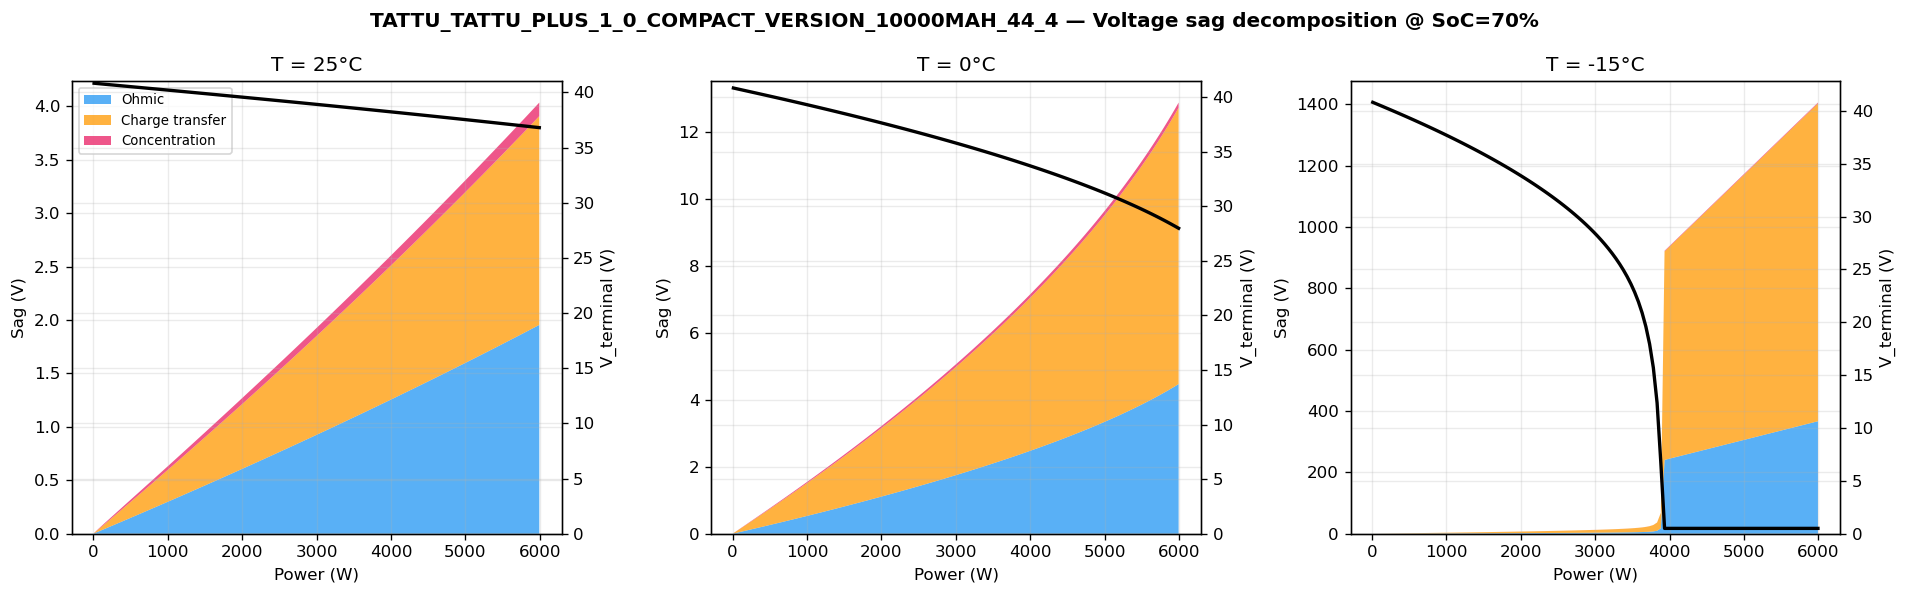

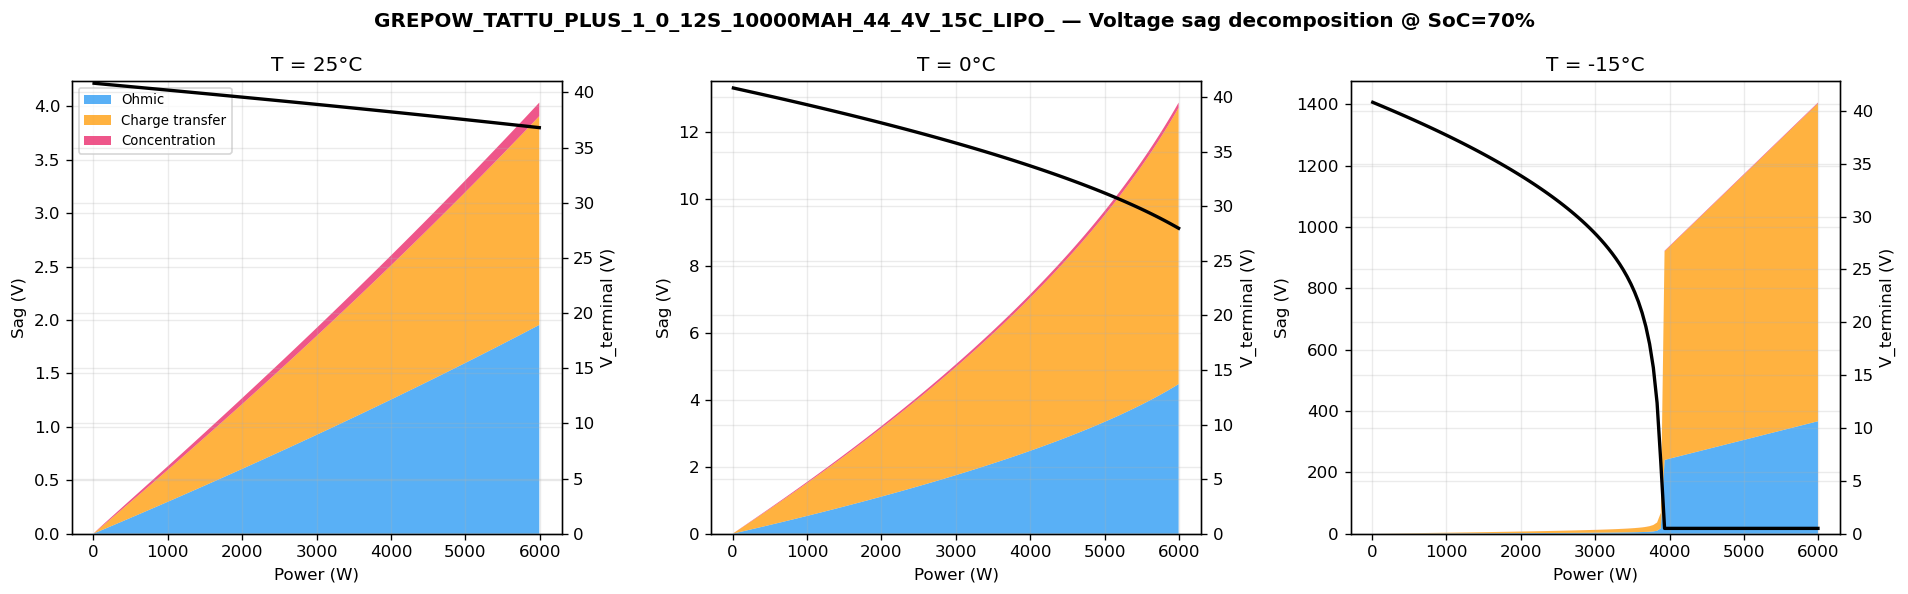

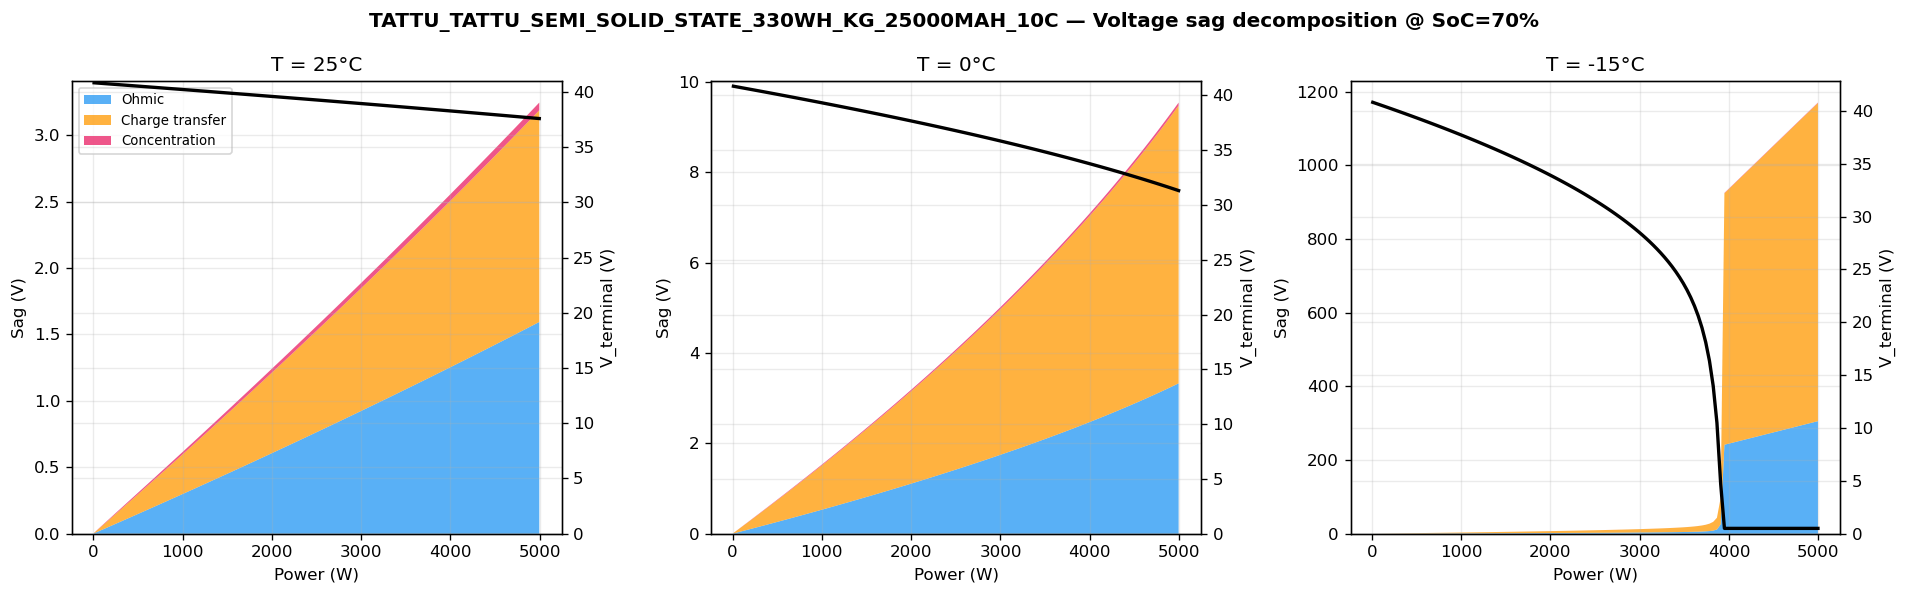

In [4]:
TEMPS_SAG  = [25, 0, -15]
SOC_FIXED  = 70.0

for _pid in selected_pack_ids:
    _pack  = db.packs[_pid]
    _powers = np.linspace(10, _pack.max_cont_discharge_w * 0.9, 120)
    _v_ocv  = _pack.pack_voltage_nom * 0.92

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"{_pid} \u2014 Voltage sag decomposition @ SoC={SOC_FIXED:.0f}%",
                 fontsize=12, fontweight="bold")

    for ax, temp in zip(axes, TEMPS_SAG):
        v_terms, dv_ohm, dv_ct, dv_conc = [], [], [], []
        for pw in _powers:
            v, i, bk = terminal_voltage(
                power_w=pw, soc_pct=SOC_FIXED, temp_c=temp,
                v_ocv_pack=_v_ocv,
                r_pack_mohm=_pack.internal_resistance_mohm,
                chem_id=_pack.chemistry_id,
                capacity_ah=_pack.pack_capacity_ah,
                cells_series=_pack.cells_series,
                cells_parallel=_pack.cells_parallel)
            v_terms.append(v)
            dv_ohm.append(bk["dv_ohmic"])
            dv_ct.append(bk["dv_ct"])
            dv_conc.append(bk["dv_conc"])

        ax.stackplot(_powers, dv_ohm, dv_ct, dv_conc,
                     labels=["Ohmic", "Charge transfer", "Concentration"],
                     colors=["#2196F3", "#FF9800", "#E91E63"], alpha=0.75)
        ax2 = ax.twinx()
        ax2.plot(_powers, v_terms, "k-", linewidth=2, label="V_terminal")
        ax2.set_ylabel("V_terminal (V)"); ax2.set_ylim(bottom=0)
        ax.set_xlabel("Power (W)"); ax.set_ylabel("Sag (V)")
        ax.set_title(f"T = {temp}\u00b0C")
        if ax is axes[0]:
            ax.legend(loc="upper left", fontsize=8)

    safe_id = _pid.replace("/", "_")[:60]
    plt.tight_layout()
    plt.savefig(f"voltage_sag_{safe_id}.png", bbox_inches="tight")
    plt.show()

## 3 · Mission Simulation (all selected batteries)

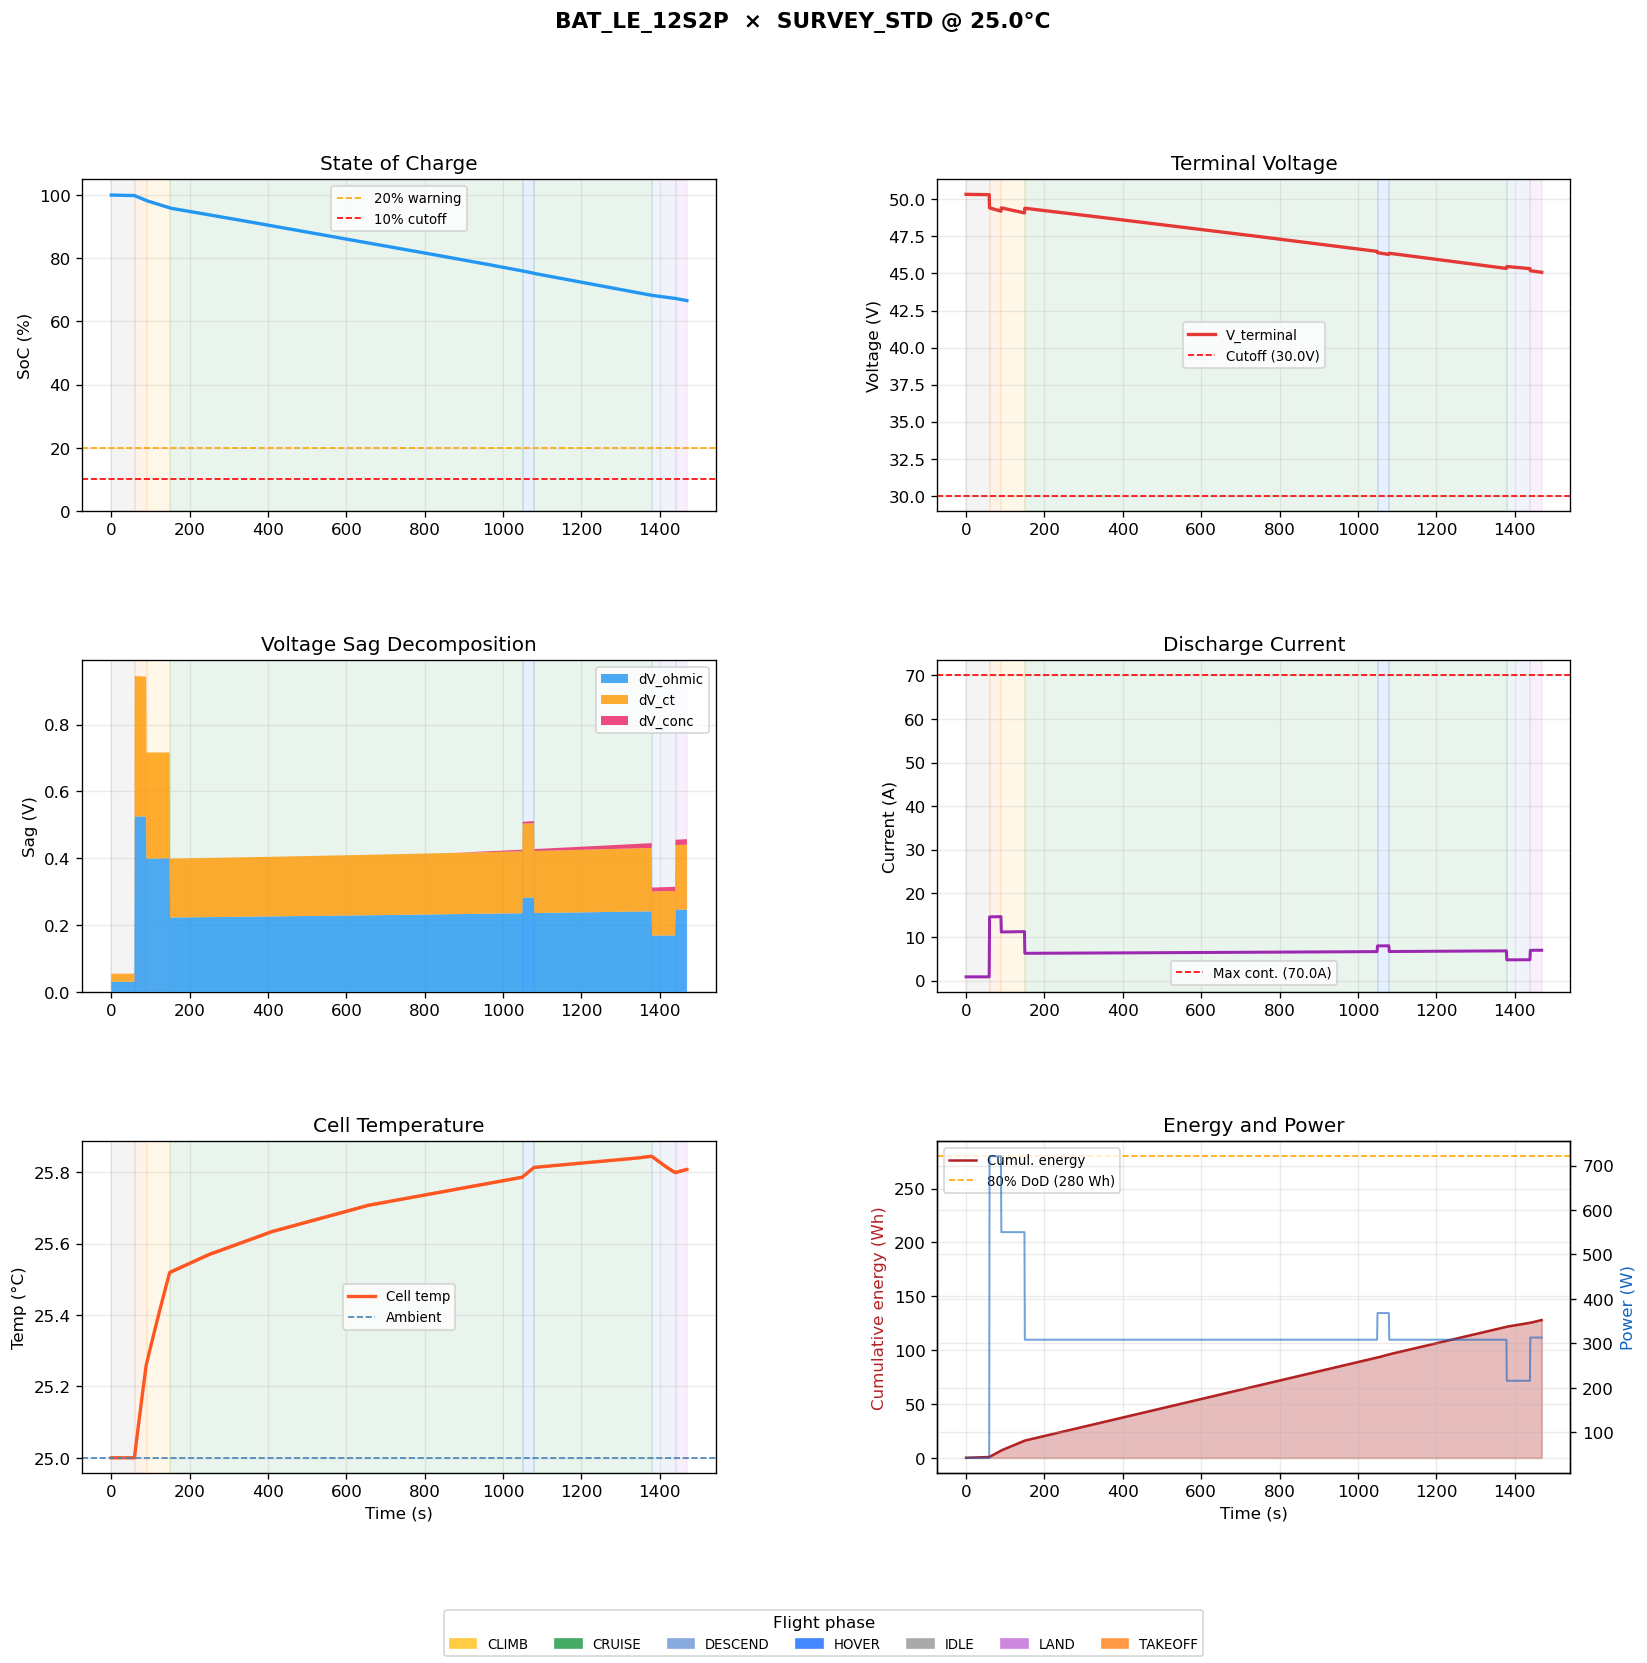

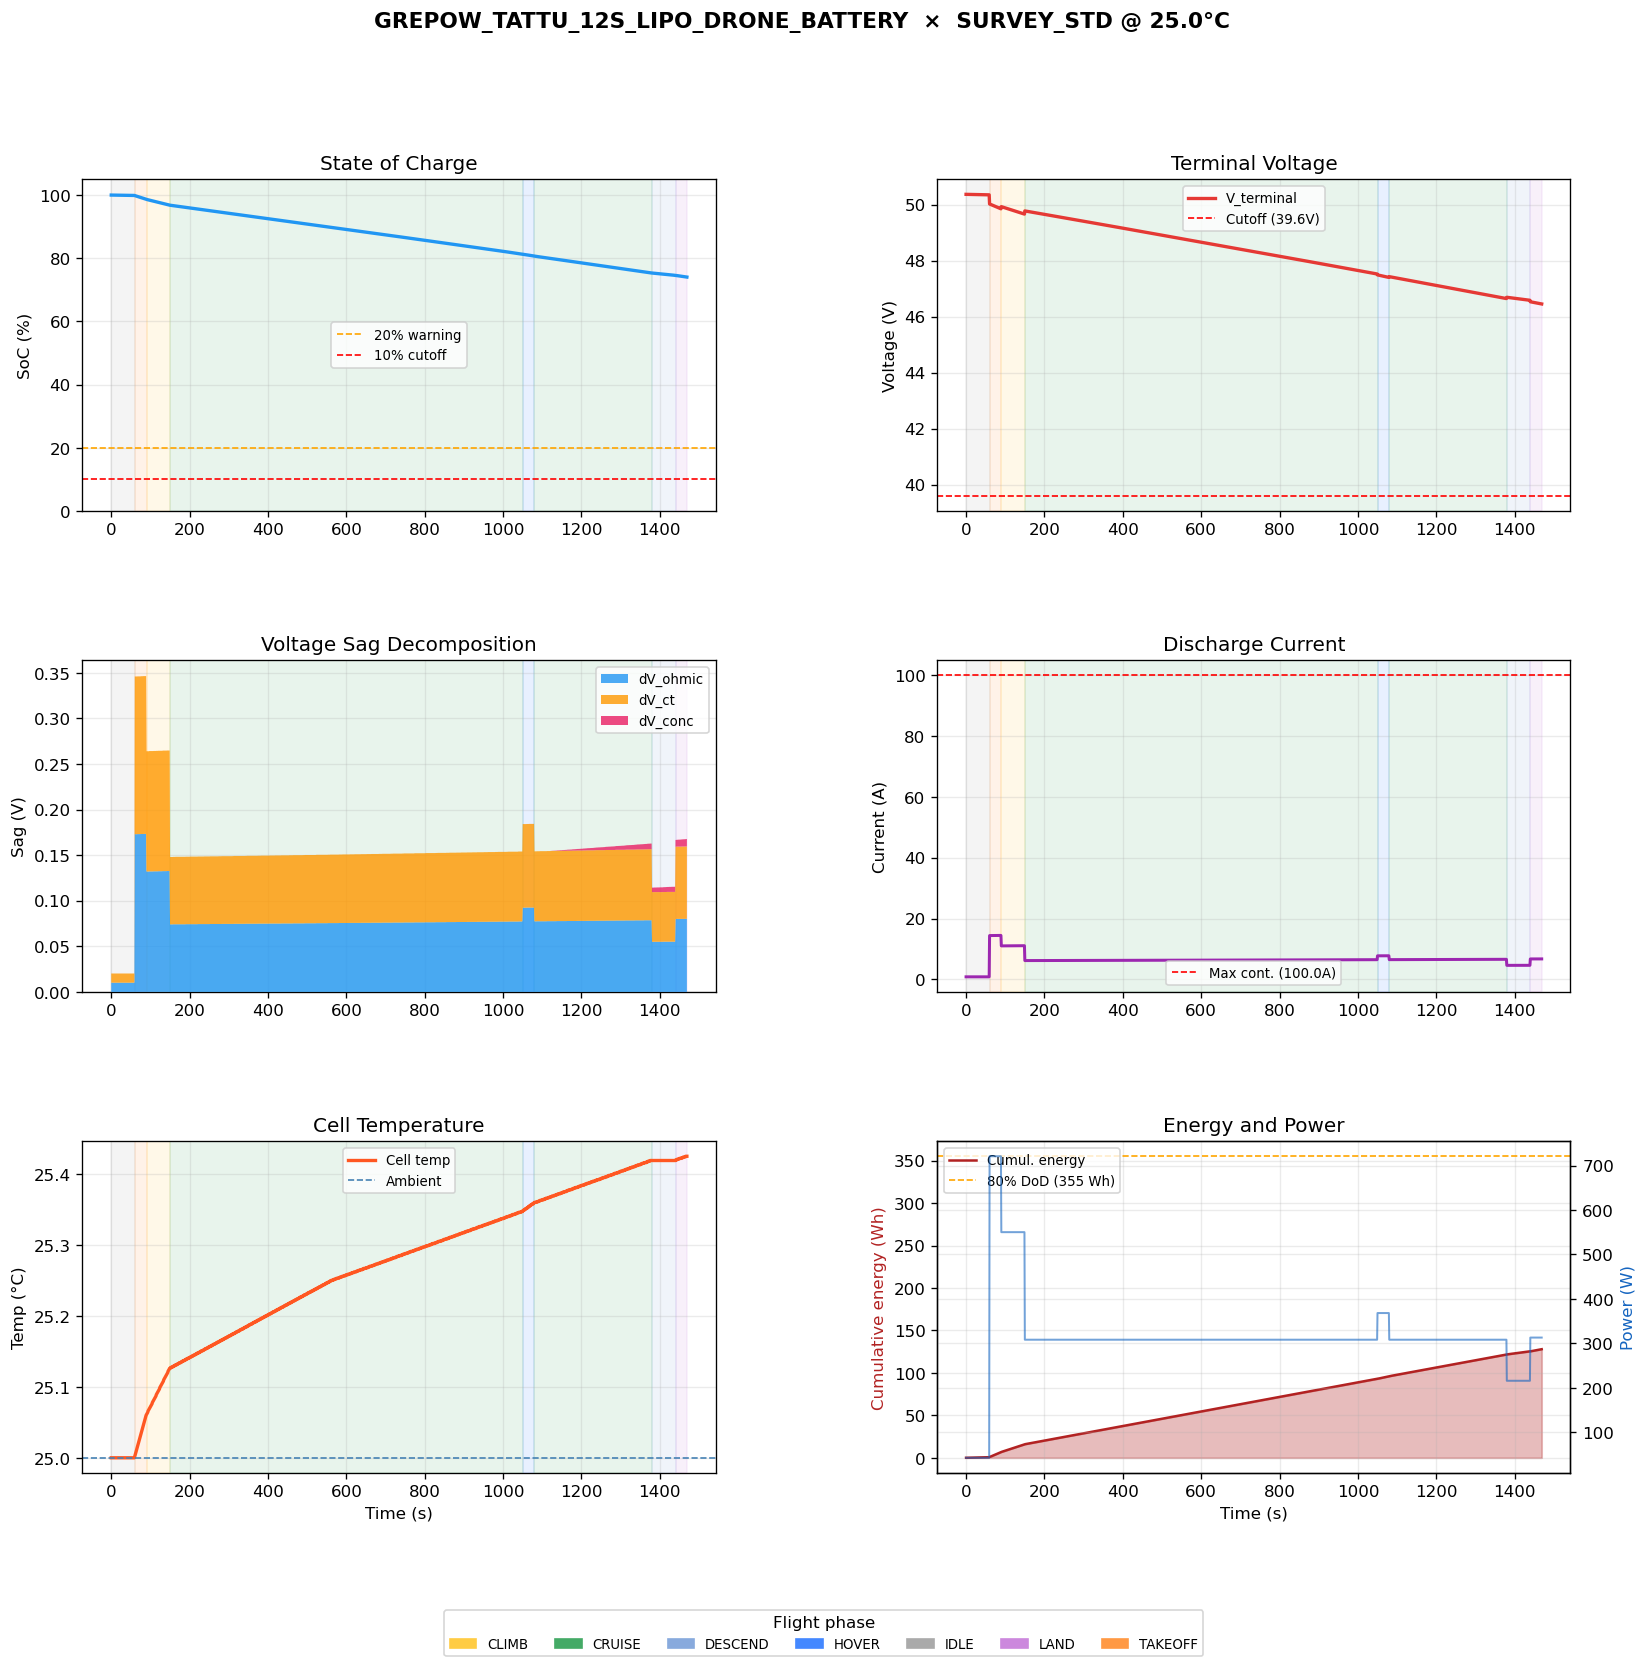

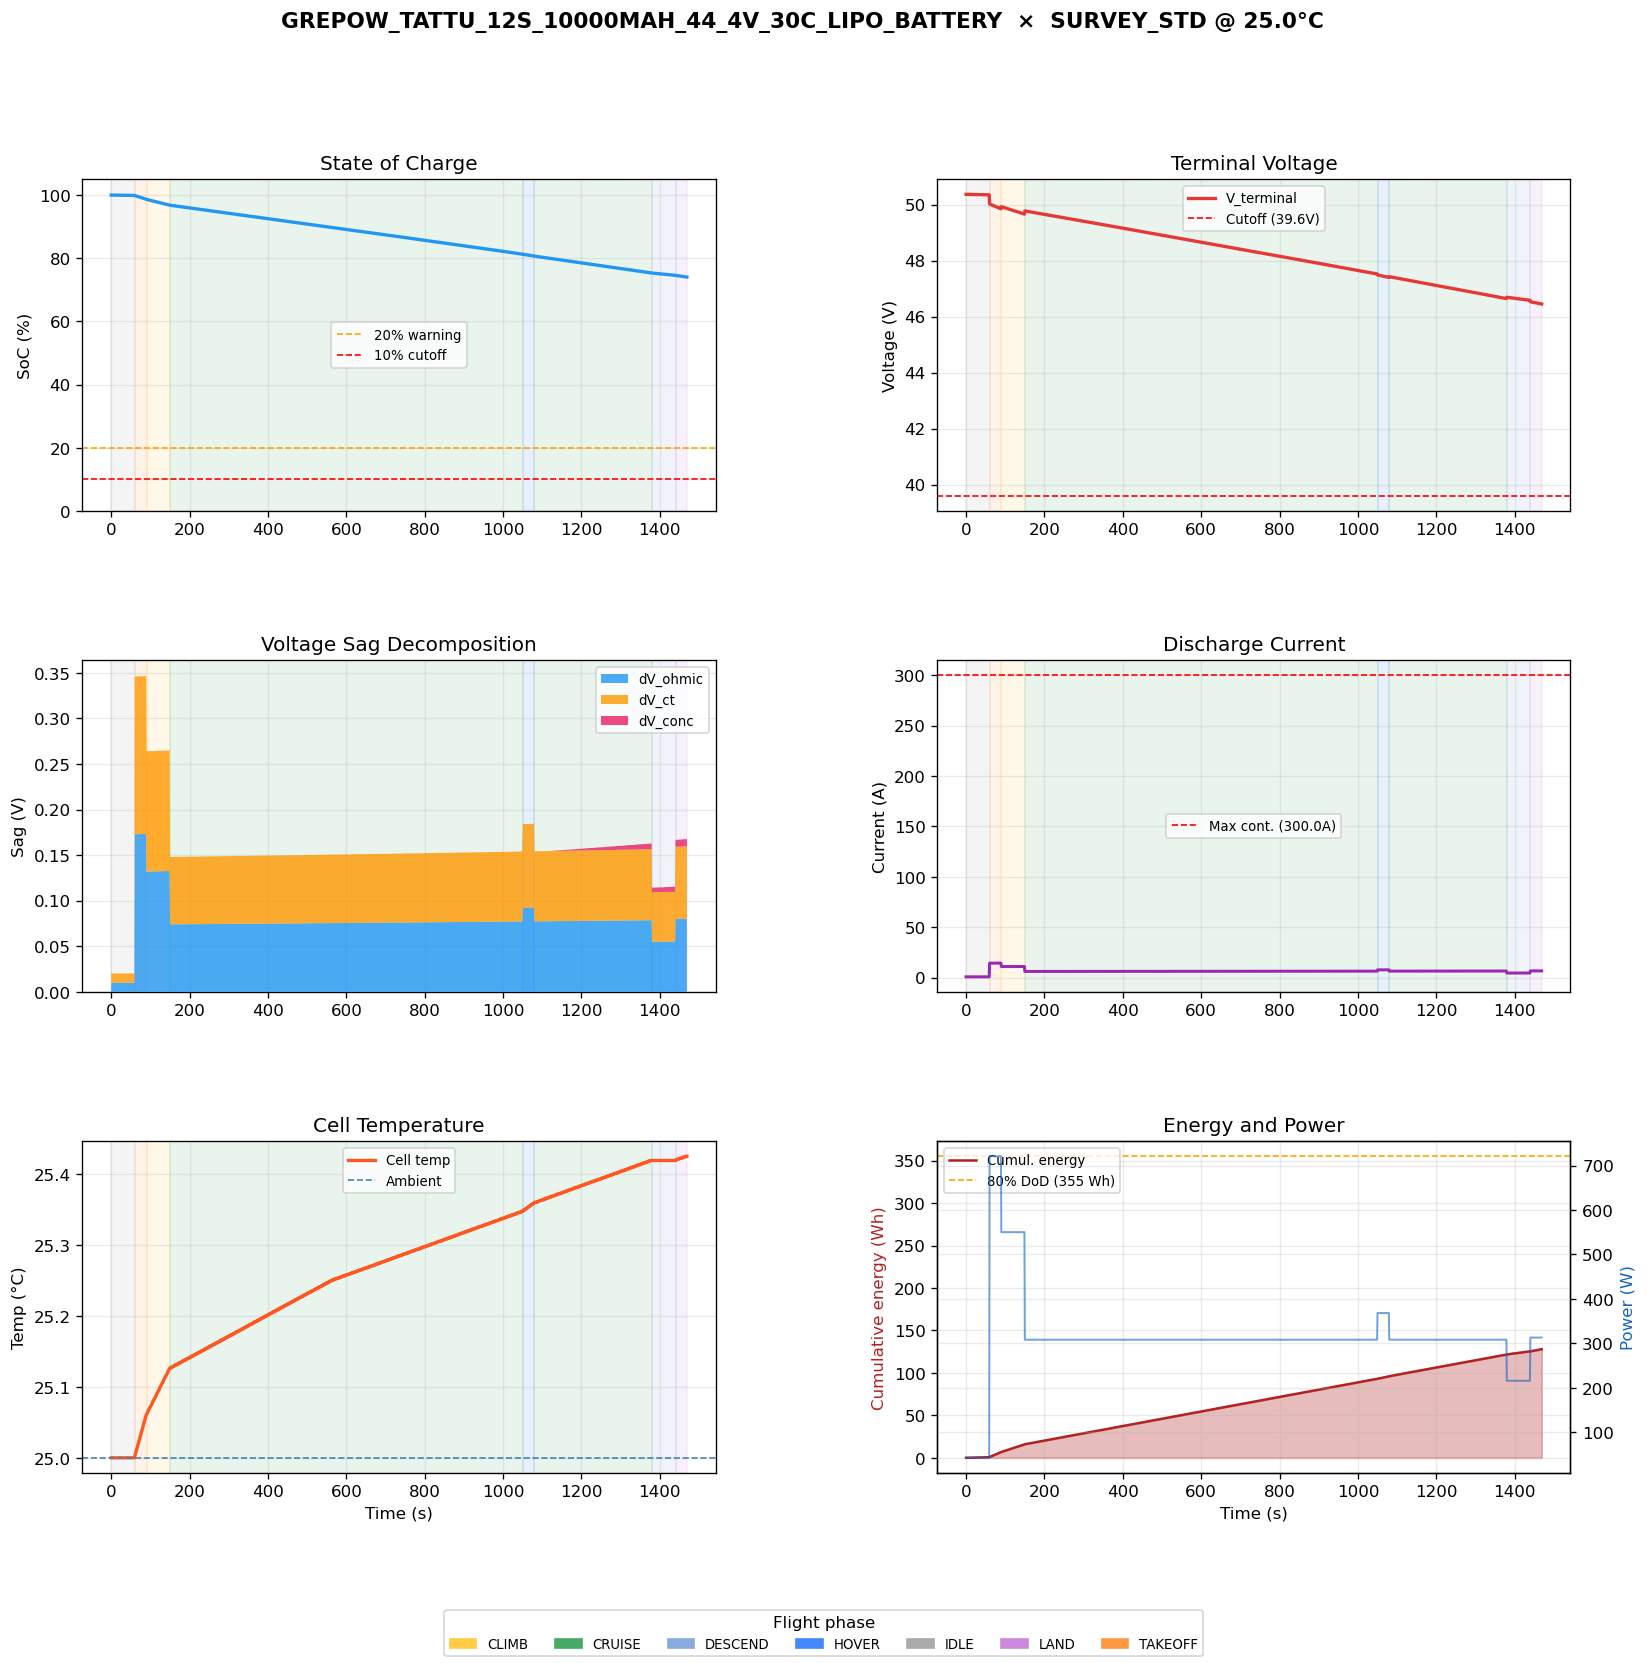

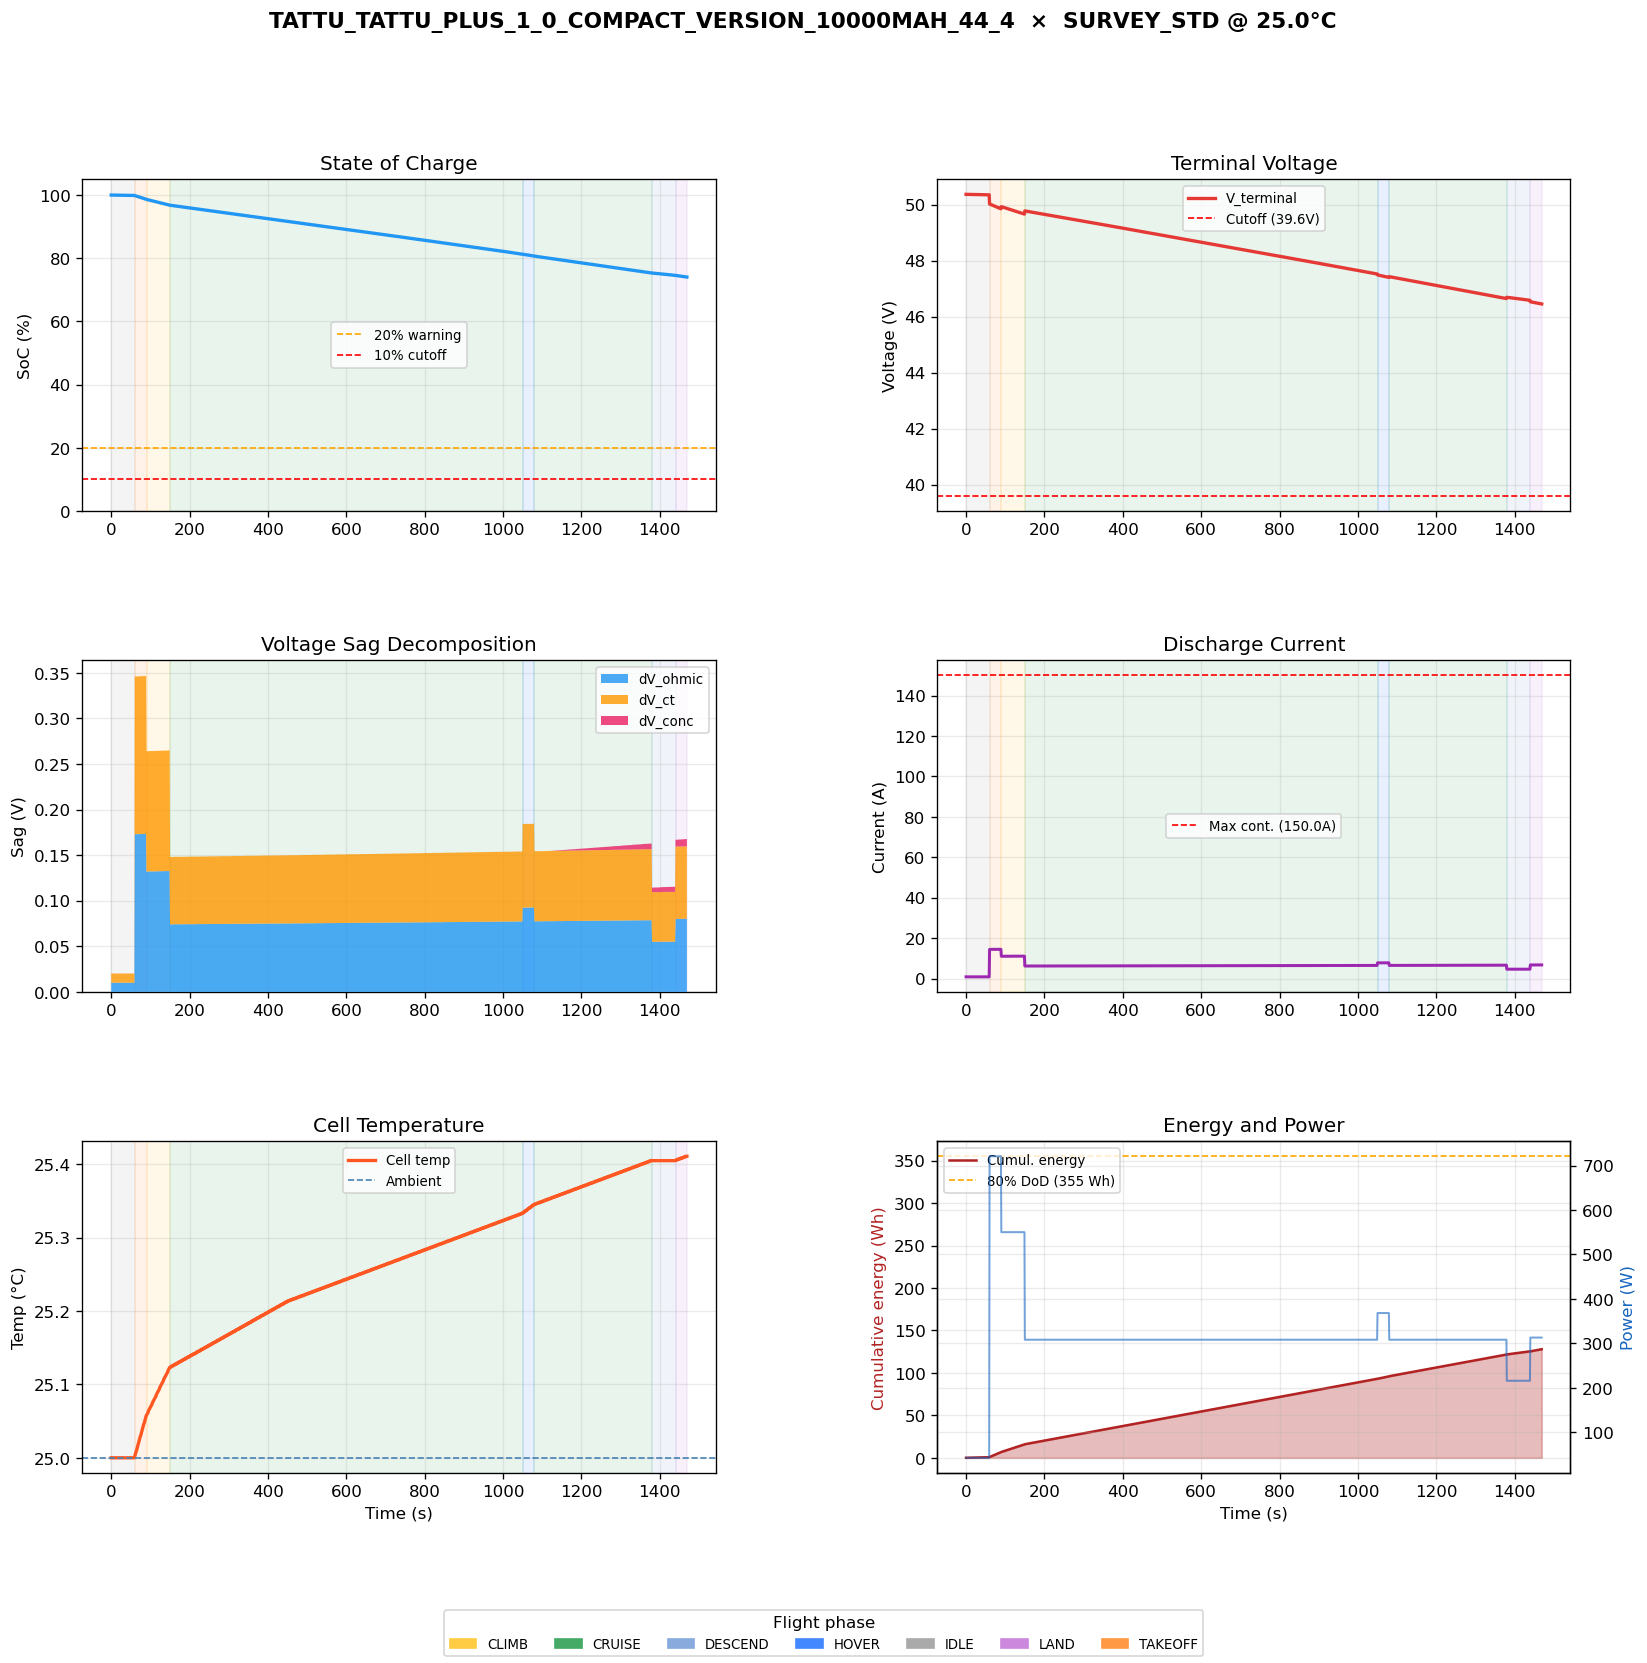

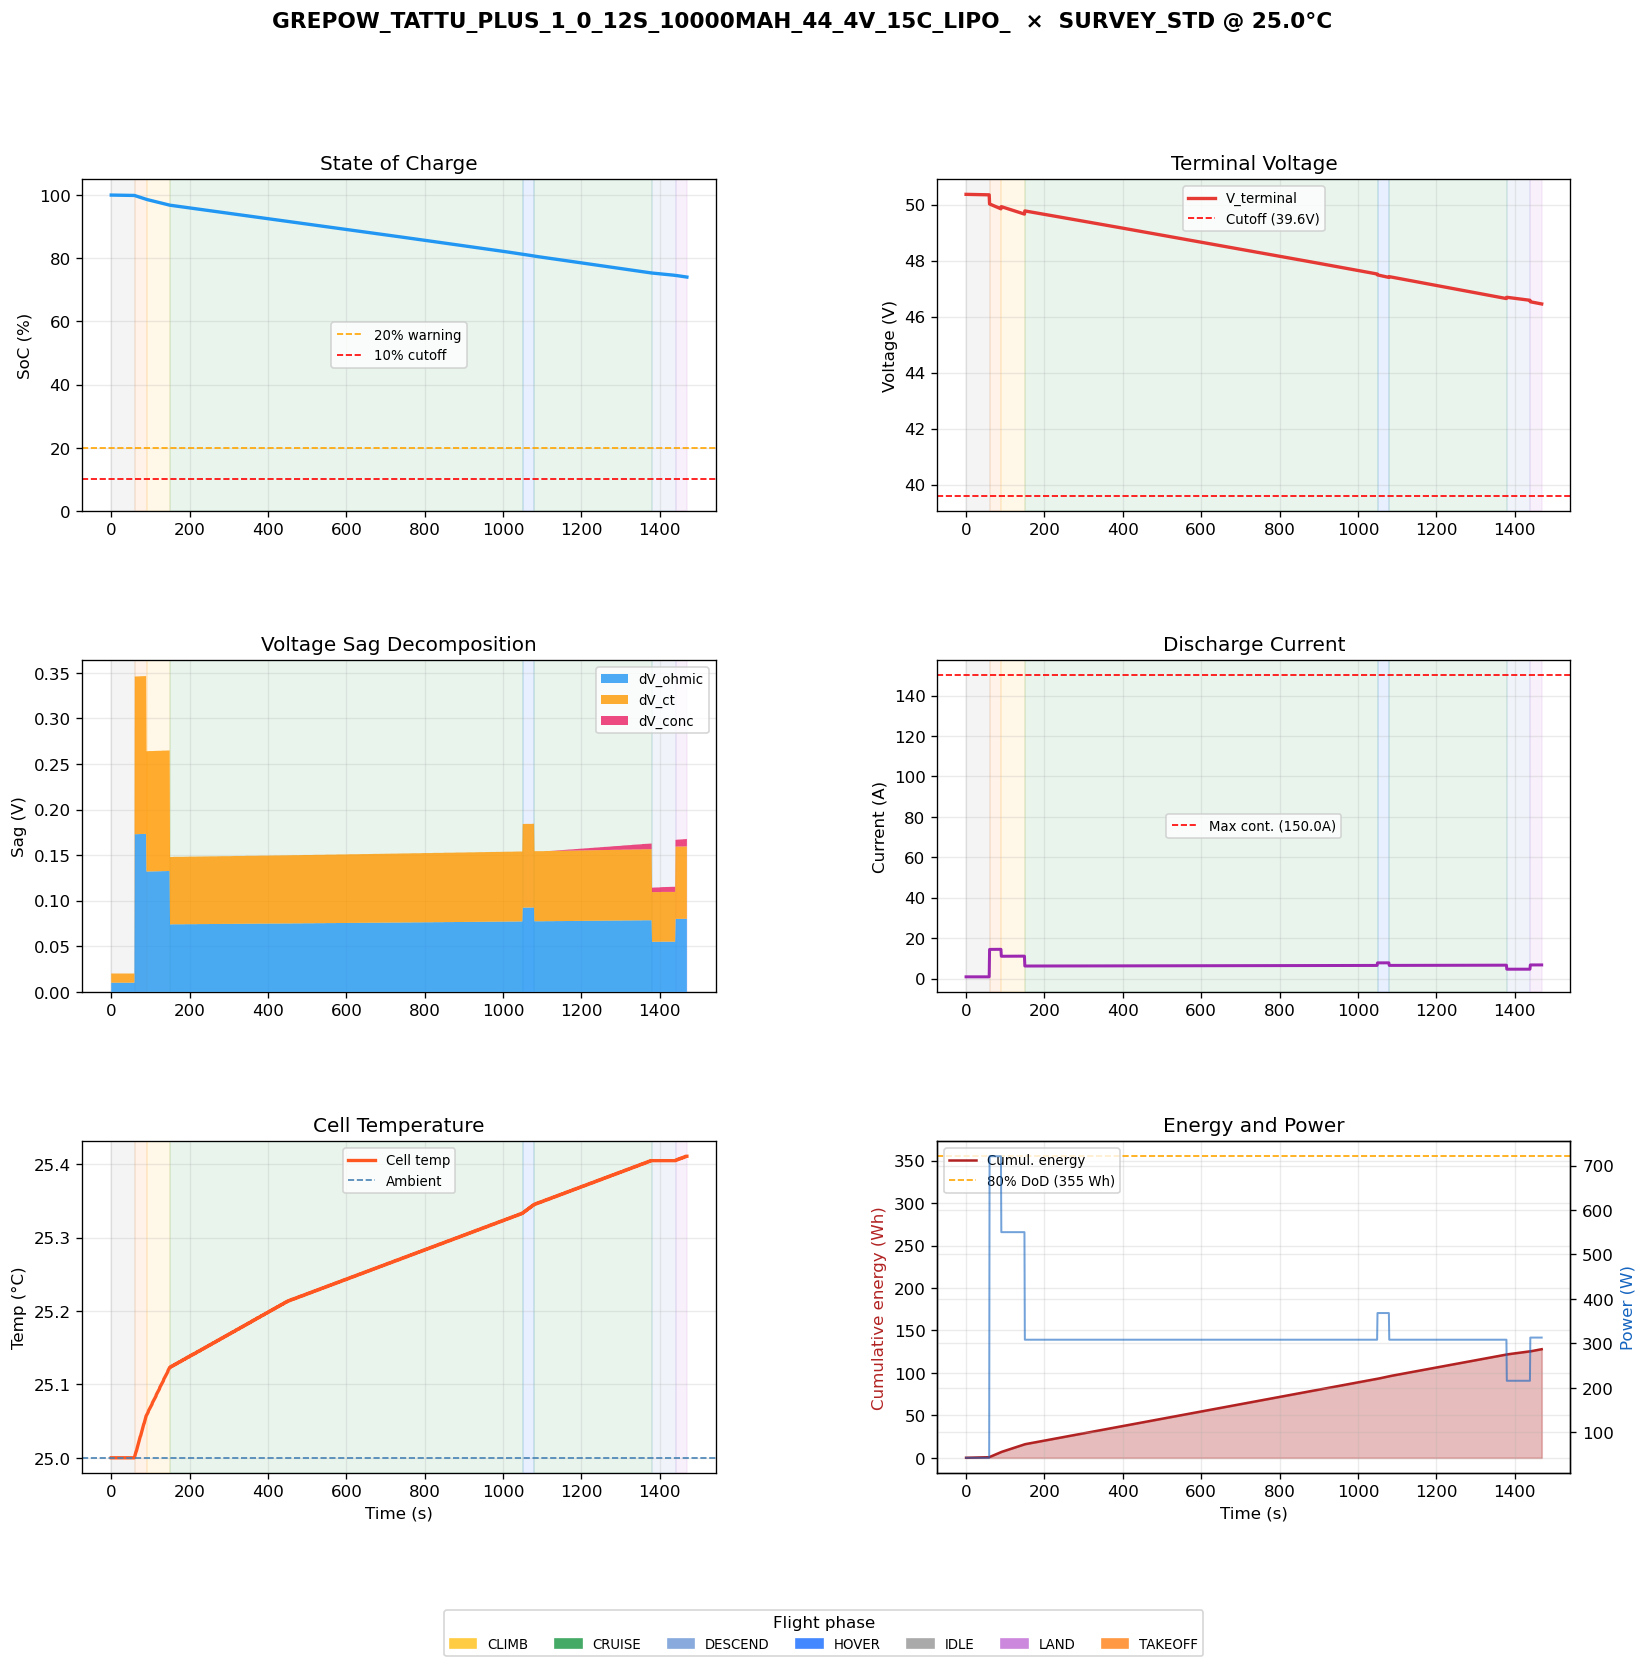

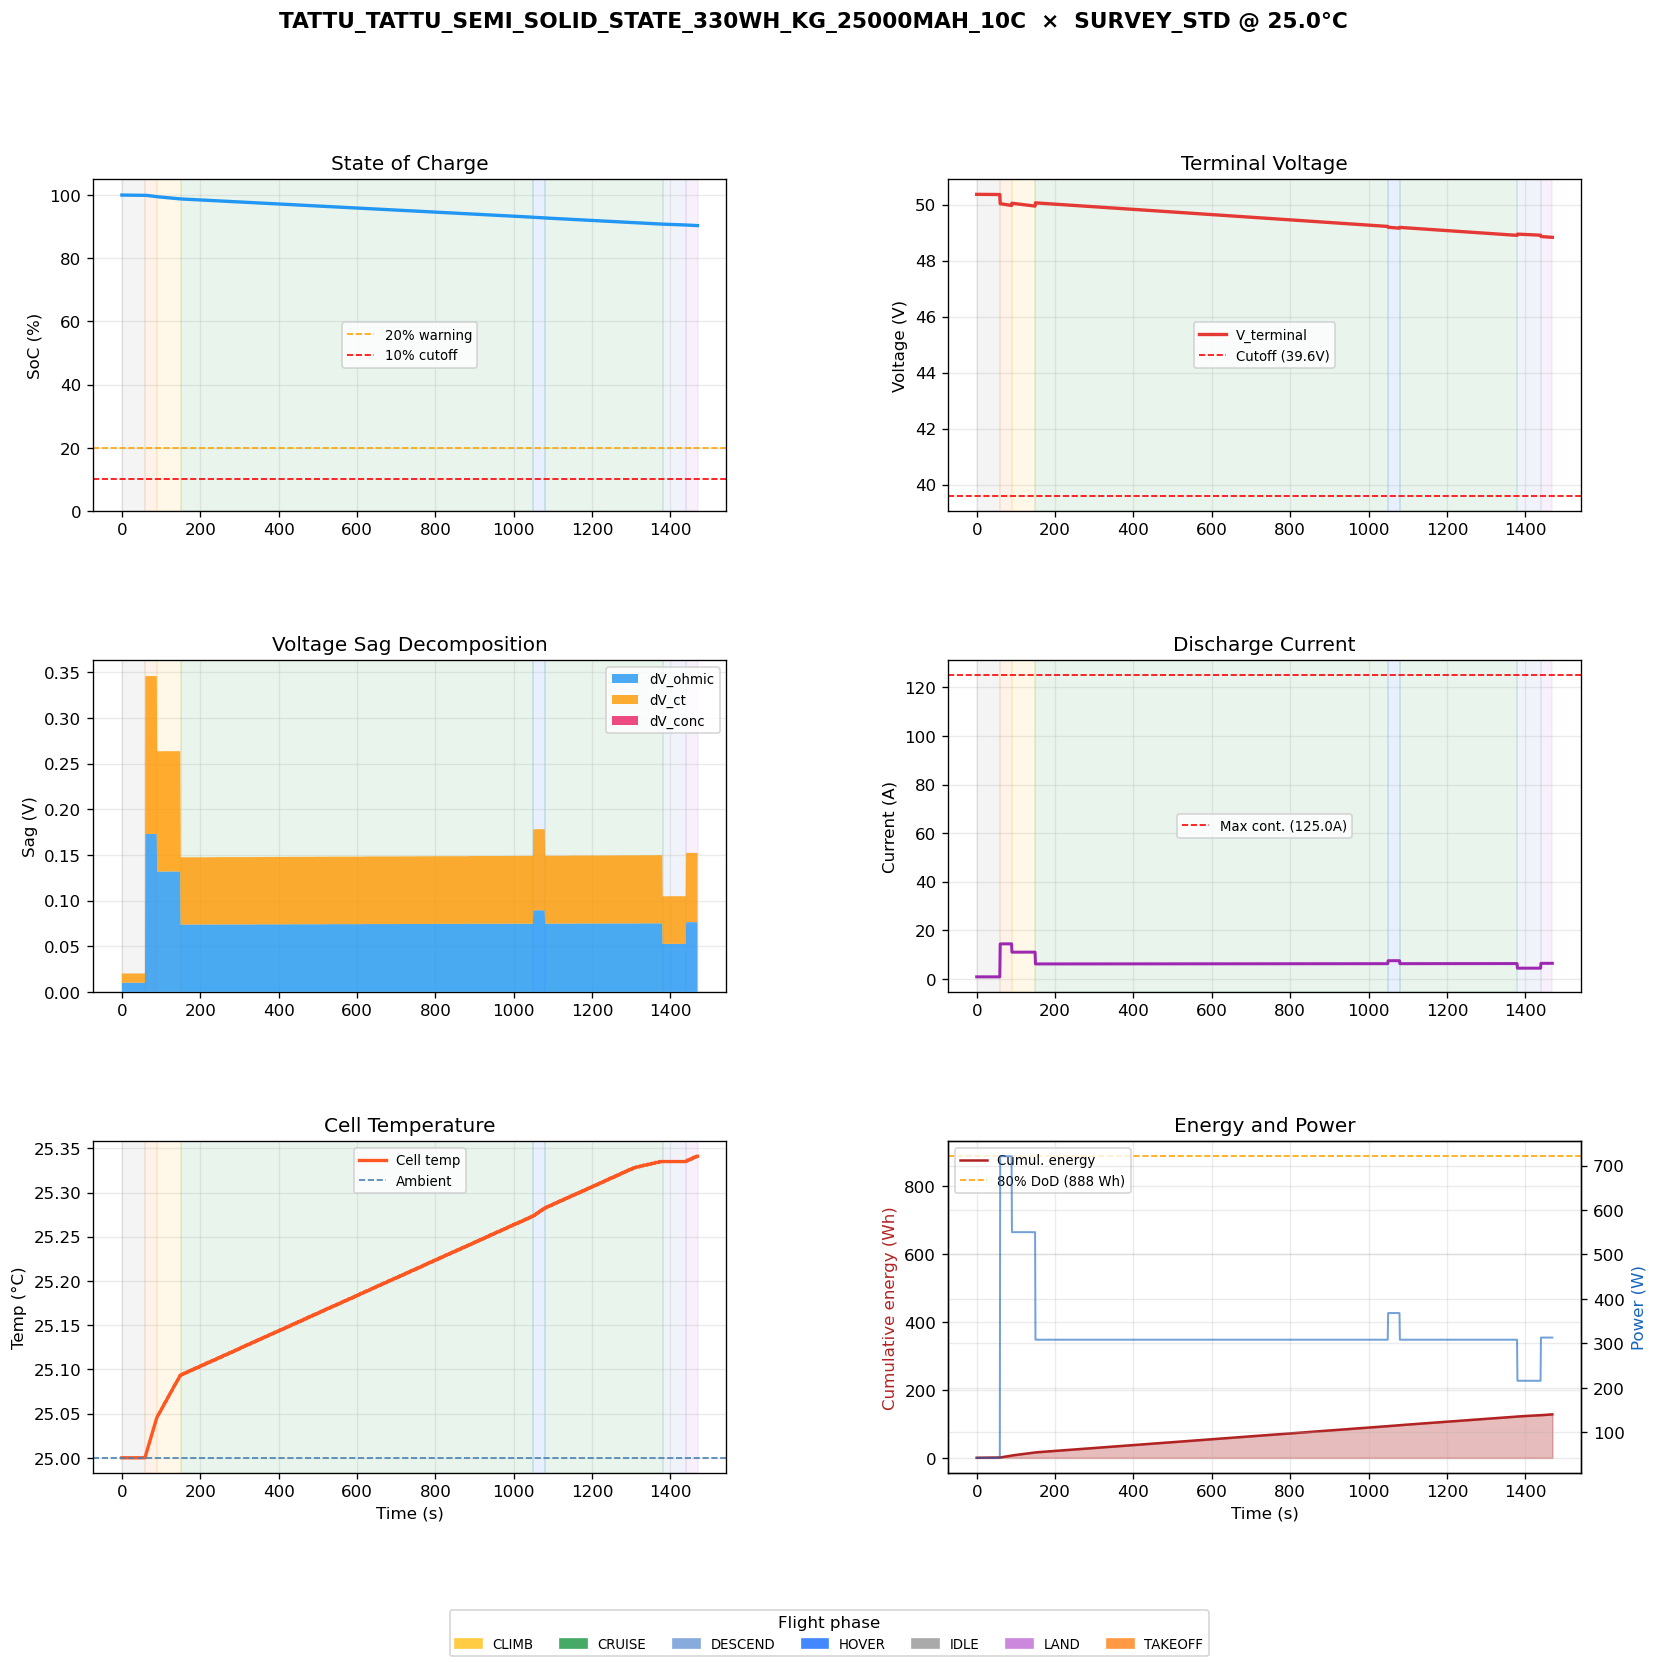

In [5]:
PHASE_COLORS = {
    "IDLE":            "#AAAAAA",
    "TAKEOFF":         "#FF9944",
    "CLIMB":           "#FFCC44",
    "CRUISE":          "#44AA66",
    "HOVER":           "#4488FF",
    "DESCEND":         "#88AADD",
    "LAND":            "#CC88DD",
    "PAYLOAD_OPS":     "#FF6688",
    "EMERGENCY":       "#FF2222",
    "VTOL_TRANSITION": "#FF6611",
    "VTOL_HOVER":      "#22AAFF",
    "FW_CRUISE":       "#00CC77",
    "FW_CLIMB":        "#AACC44",
    "FW_DESCEND":      "#99CCEE",
}

def shade_phases(ax, res):
    prev, t0 = res.phase_type[0], res.time_s[0]
    for t, ph in zip(res.time_s[1:], res.phase_type[1:]):
        if ph != prev:
            ax.axvspan(t0, t, alpha=0.12, color=PHASE_COLORS.get(prev, "#CCC"))
            t0 = t
        prev = ph
    ax.axvspan(t0, res.time_s[-1], alpha=0.12, color=PHASE_COLORS.get(prev, "#CCC"))

for _pid in selected_pack_ids:
    _pack = db.packs[_pid]
    res   = all_results[_pid]
    t     = np.array(res.time_s)

    fig = plt.figure(figsize=(16, 14))
    gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
    fig.suptitle(f"{_pid}  \u00d7  {SIM_MISSION_ID} @ {AMBIENT_TEMP_C}\u00b0C",
                 fontsize=13, fontweight="bold")

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(t, res.soc_pct, "#2196F3", linewidth=2)
    ax1.axhline(20, color="orange", linestyle="--", linewidth=1, label="20% warning")
    ax1.axhline(10, color="red",    linestyle="--", linewidth=1, label="10% cutoff")
    shade_phases(ax1, res)
    ax1.set_ylabel("SoC (%)"); ax1.set_title("State of Charge")
    ax1.legend(fontsize=8); ax1.set_ylim(0, 105)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(t, res.voltage_v, "#E53935", linewidth=2, label="V_terminal")
    ax2.axhline(_pack.pack_voltage_cutoff, color="red", linestyle="--", linewidth=1,
                label=f"Cutoff ({_pack.pack_voltage_cutoff}V)")
    shade_phases(ax2, res)
    ax2.set_ylabel("Voltage (V)"); ax2.set_title("Terminal Voltage")
    ax2.legend(fontsize=8)

    ax3 = fig.add_subplot(gs[1, 0])
    ax3.stackplot(t, res.dv_ohmic, res.dv_ct, res.dv_conc,
                  labels=["dV_ohmic", "dV_ct", "dV_conc"],
                  colors=["#2196F3", "#FF9800", "#E91E63"], alpha=0.80, zorder=3)
    shade_phases(ax3, res)
    ax3.set_ylabel("Sag (V)"); ax3.set_title("Voltage Sag Decomposition")
    ax3.legend(fontsize=8, loc="upper right")

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(t, res.current_a, "#9C27B0", linewidth=1.8)
    ax4.axhline(_pack.max_cont_discharge_a, color="red", linestyle="--", linewidth=1,
                label=f"Max cont. ({_pack.max_cont_discharge_a}A)")
    shade_phases(ax4, res)
    ax4.set_ylabel("Current (A)"); ax4.set_title("Discharge Current")
    ax4.legend(fontsize=8)

    ax5 = fig.add_subplot(gs[2, 0])
    ax5.plot(t, res.temp_c, "#FF5722", linewidth=2, label="Cell temp")
    ax5.axhline(AMBIENT_TEMP_C, color="steelblue", linestyle="--", linewidth=1, label="Ambient")
    shade_phases(ax5, res)
    ax5.set_xlabel("Time (s)"); ax5.set_ylabel("Temp (\u00b0C)")
    ax5.set_title("Cell Temperature"); ax5.legend(fontsize=8)

    ax6  = fig.add_subplot(gs[2, 1])
    ax6b = ax6.twinx()
    ax6.fill_between(t, res.energy_wh, alpha=0.3, color="firebrick")
    ax6.plot(t, res.energy_wh, "firebrick", linewidth=1.5, label="Cumul. energy")
    ax6b.plot(t, res.power_w, "#1565C0", linewidth=1.2, alpha=0.6)
    ax6.axhline(_pack.pack_energy_wh * 0.80, color="orange", linestyle="--", linewidth=1,
                label=f"80% DoD ({_pack.pack_energy_wh * 0.8:.0f} Wh)")
    ax6.set_xlabel("Time (s)")
    ax6.set_ylabel("Cumulative energy (Wh)", color="firebrick")
    ax6b.set_ylabel("Power (W)", color="#1565C0")
    ax6.set_title("Energy and Power")
    ax6.legend(fontsize=8, loc="upper left")

    patches = [mpatches.Patch(color=PHASE_COLORS.get(p, "#888"), label=p)
               for p in sorted(set(res.phase_type))]
    fig.legend(handles=patches, loc="lower center", ncol=8, fontsize=8,
               title="Flight phase")

    safe_id = _pid.replace("/", "_")[:60]
    plt.savefig(f"simulation_{safe_id}.png", bbox_inches="tight")
    plt.show()

## 4 · Temperature Sensitivity Analysis

In [6]:
TEMPS_SWEEP = [-25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45]

print(f'Running temperature sweep for {len(selected_pack_ids)} pack(s) '
      f'over {len(TEMPS_SWEEP)} temperatures ...')

all_sweeps   = {}   # pid -> (list of SimResult)
all_df_sweep = {}   # pid -> DataFrame

for _pid in selected_pack_ids:
    _pack = db.packs[_pid]
    _res  = temperature_sweep(
        pack=_pack, mission=mission, uav=uav,
        discharge_pts=db.discharge_pts,
        temperatures_c=TEMPS_SWEEP, dt_s=5.0)
    all_sweeps[_pid] = _res
    all_df_sweep[_pid] = pd.DataFrame([{
        "Ambient (C)":      t,
        "Final SoC (%)":    round(r.final_soc, 1),
        "Duration (s)":     round(r.total_duration_s, 0),
        "Energy used (Wh)": round(r.total_energy_consumed_wh, 1),
        "Min V (V)":        round(r.min_voltage, 3),
        "Peak sag (V)":     round(r.peak_sag_v, 3),
        "Max I (A)":        round(r.max_current, 1),
        "Max T (\u00b0C)":   round(r.max_temp_c, 1),
        "Depleted":         r.depleted,
        "Cutoff":           r.cutoff_reason or "none",
    } for t, r in zip(TEMPS_SWEEP, _res)])
    print(f'\n{_pid}:')
    print(all_df_sweep[_pid].to_string(index=False))

# Keep first-pack alias for the chart cell
df_sweep = all_df_sweep[selected_pack_ids[0]]

Running temperature sweep for 6 pack(s) over 15 temperatures ...

BAT_LE_12S2P:
 Ambient (C)  Final SoC (%)  Duration (s)  Energy used (Wh)  Min V (V)  Peak sag (V)  Max I (A)  Max T (°C)  Depleted Cutoff
         -25           42.8        1465.0             127.9     39.678         6.023       16.3       -20.0     False   none
         -20           46.4        1465.0             127.9     40.637         4.683       15.8       -16.0     False   none
         -15           50.6        1465.0             127.9     41.593         3.719       15.5       -11.7     False   none
         -10           54.2        1465.0             127.9     42.400         3.005       15.3        -7.3     False   none
          -5           57.4        1465.0             127.9     43.083         2.465       15.1        -2.8     False   none
           0           60.1        1465.0             127.9     43.645         2.048       15.0         1.8     False   none
           5           62.1        1465.0    

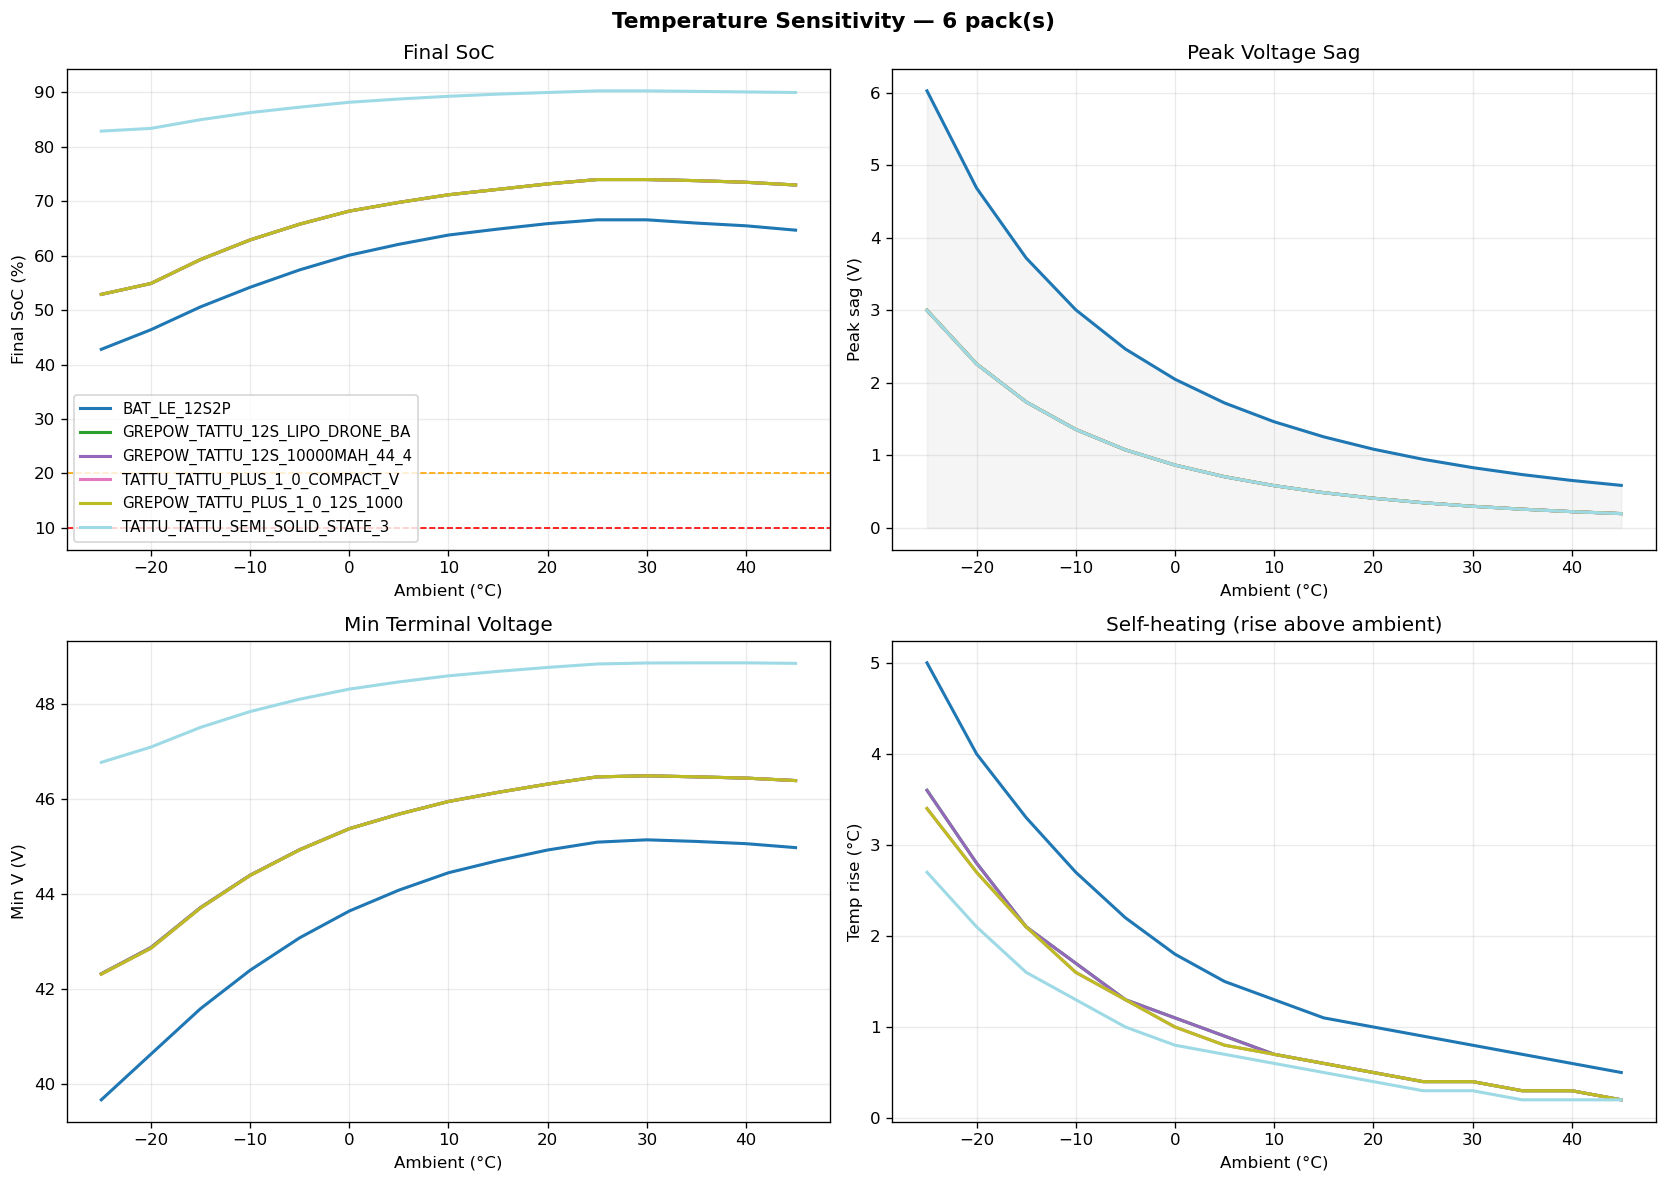

In [7]:
import matplotlib.cm as _cm2

n_sw    = len(selected_pack_ids)
_cmap2  = _cm2.get_cmap('tab20', max(n_sw, 1))
sw_cols = [_cmap2(i) for i in range(n_sw)]
lw_sw   = max(0.9, 2.2 - n_sw * 0.06)
leg_sw  = max(5, min(9, int(130 / n_sw)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Temperature Sensitivity — {len(selected_pack_ids)} pack(s)",
             fontsize=13, fontweight="bold")

for _pid, col in zip(selected_pack_ids, sw_cols):
    df = all_df_sweep[_pid]
    _pack = db.packs[_pid]
    t_vals = df["Ambient (C)"].values
    lbl    = _pid[:30]

    axes[0, 0].plot(t_vals, df["Final SoC (%)"],    color=col, linewidth=lw_sw, label=lbl)
    axes[0, 1].plot(t_vals, df["Peak sag (V)"],     color=col, linewidth=lw_sw)
    axes[1, 0].plot(t_vals, df["Min V (V)"],        color=col, linewidth=lw_sw)
    axes[1, 1].plot(t_vals, df["Max T (\u00b0C)"] - t_vals, color=col, linewidth=lw_sw)

axes[0, 0].axhline(20, color="orange", linestyle="--", linewidth=1)
axes[0, 0].axhline(10, color="red",    linestyle="--", linewidth=1)
axes[0, 0].set_xlabel("Ambient (\u00b0C)"); axes[0, 0].set_ylabel("Final SoC (%)")
axes[0, 0].set_title("Final SoC")

axes[0, 1].fill_between(t_vals, 0, all_df_sweep[selected_pack_ids[0]]["Peak sag (V)"],
                         alpha=0.08, color="grey")
axes[0, 1].set_xlabel("Ambient (\u00b0C)"); axes[0, 1].set_ylabel("Peak sag (V)")
axes[0, 1].set_title("Peak Voltage Sag")

axes[1, 0].set_xlabel("Ambient (\u00b0C)"); axes[1, 0].set_ylabel("Min V (V)")
axes[1, 0].set_title("Min Terminal Voltage")

axes[1, 1].set_xlabel("Ambient (\u00b0C)"); axes[1, 1].set_ylabel("Temp rise (\u00b0C)")
axes[1, 1].set_title("Self-heating (rise above ambient)")

if n_sw <= 8:
    axes[0, 0].legend(fontsize=leg_sw, loc="lower left")
else:
    fig.legend(loc="lower center", ncol=min(n_sw, 4),
               fontsize=leg_sw, bbox_to_anchor=(0.5, 0.0))
    plt.tight_layout(rect=[0, max(0.03, n_sw * 0.009), 1, 1])

plt.tight_layout()
plt.savefig("temperature_sensitivity.png", bbox_inches="tight", dpi=120)
plt.show()

## 5 · Multi-Battery Comparison

════════════════════════════════════════════════════
 Simulation: BAT_LE_12S2P × SURVEY_STD  [COMPLETED]
════════════════════════════════════════════════════
  Duration         : 1468 s  (24.5 min)
  Energy consumed  : 127.91 Wh
  Initial SoC      : 100.0 %
  Final SoC        : 64.9 %
  Min voltage      : 44.693 V
  Max current      : 14.7 A
  Peak sag total   : 1.254 V
  Peak temperature : 16.1 °C

════════════════════════════════════════════════════
 Simulation: GREPOW_TATTU_12S_LIPO_DRONE_BATTERY × SURVEY_STD  [COMPLETED]
════════════════════════════════════════════════════
  Duration         : 1468 s  (24.5 min)
  Energy consumed  : 127.91 Wh
  Initial SoC      : 100.0 %
  Final SoC        : 72.2 %
  Min voltage      : 46.131 V
  Max current      : 14.5 A
  Peak sag total   : 0.484 V
  Peak temperature : 15.6 °C

════════════════════════════════════════════════════
 Simulation: GREPOW_TATTU_12S_10000MAH_44_4V_30C_LIPO_BATTERY × SURVEY_STD  [COMPLETED]
══════════════════════════════

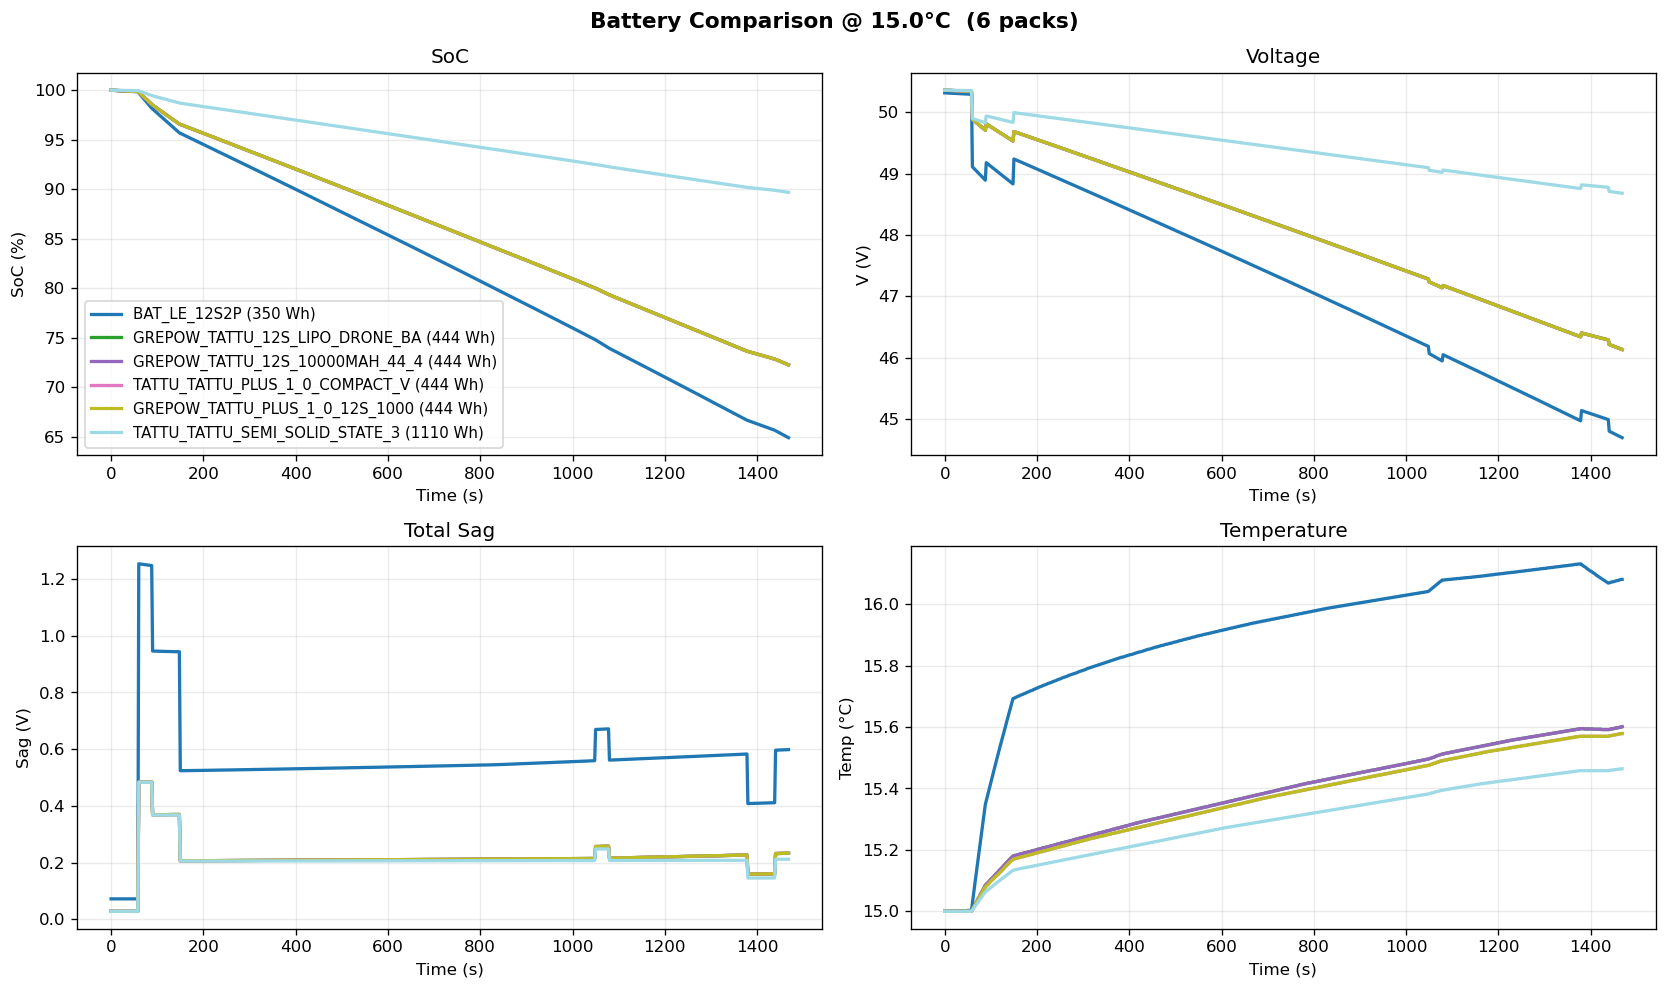

In [8]:
# COMPARE_PACK_IDS is loaded from analysis_config.json in the cell above.
# Override here if you want a specific subset:
# COMPARE_PACK_IDS = ["BAT_MID_6S2P", "BAT_MID_6S4P"]

COMPARE_TEMP = 15.0   # ambient temperature for comparison run

# ── Filter to packs that exist in db ─────────────────────────────────────────
valid_ids = [pid for pid in COMPARE_PACK_IDS if pid in db.packs]
if not valid_ids:
    print('No valid pack IDs in COMPARE_PACK_IDS — check battery selector output.')
else:
    compare_packs = [db.packs[pid] for pid in valid_ids]
    compare_results = compare_batteries(
        packs=compare_packs, mission=mission, uav=uav,
        discharge_pts=db.discharge_pts, ambient_temp_c=COMPARE_TEMP, dt_s=2.0)
    for r in compare_results:
        print(r.summary()); print()

    n_packs = len(compare_packs)

    # ── Generate a colour per pack from a qualitative colourmap ──────────────
    import matplotlib.cm as _cm
    _cmap = _cm.get_cmap('tab20', max(n_packs, 1))
    palette = [_cmap(i) for i in range(n_packs)]

    # ── Chart — line width and legend font scale with battery count ───────────
    lw      = max(0.8, 2.2 - n_packs * 0.04)
    leg_fs  = max(5, min(9, int(130 / n_packs)))
    fig_h   = max(8, min(14, 8 + n_packs * 0.06))

    fig, axes = plt.subplots(2, 2, figsize=(14, fig_h))
    fig.suptitle(f"Battery Comparison @ {COMPARE_TEMP}°C  ({n_packs} packs)",
                 fontsize=13, fontweight="bold")

    for r, p, col in zip(compare_results, compare_packs, palette):
        label = f"{r.pack_id[:30]} ({p.pack_energy_wh:.0f} Wh)"
        t_arr = np.array(r.time_s)
        axes[0,0].plot(t_arr, r.soc_pct,      color=col, linewidth=lw, label=label)
        axes[0,1].plot(t_arr, r.voltage_v,     color=col, linewidth=lw)
        axes[1,0].plot(t_arr,
                       np.array(r.dv_ohmic) + np.array(r.dv_ct) + np.array(r.dv_conc),
                       color=col, linewidth=lw)
        axes[1,1].plot(t_arr, r.temp_c,        color=col, linewidth=lw)

    for ax, (title, ylabel) in zip(axes.flat, [
            ("SoC",         "SoC (%)"),
            ("Voltage",     "V (V)"),
            ("Total Sag",   "Sag (V)"),
            ("Temperature", "Temp (°C)"),
    ]):
        ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xlabel("Time (s)")

    # Legend below chart when there are many packs, inside when few
    if n_packs <= 8:
        axes[0,0].legend(fontsize=leg_fs, loc="lower left")
    else:
        fig.legend(loc="lower center", ncol=min(n_packs, 4),
                   fontsize=leg_fs, bbox_to_anchor=(0.5, 0.0))
        plt.tight_layout(rect=[0, max(0.02, n_packs * 0.008), 1, 1])

    plt.tight_layout()
    plt.savefig("multi_battery_compare.png", bbox_inches="tight", dpi=120)
    plt.show()

## 7 · Export Simulation Results

In [9]:
import os as _os2
_export_dir = 'simulation_results'
_os2.makedirs(_export_dir, exist_ok=True)

for _pid, res in all_results.items():
    df_out = pd.DataFrame({
        "time_s":       res.time_s,
        "phase":        res.phase_type,
        "soc_pct":      res.soc_pct,
        "voltage_v":    res.voltage_v,
        "current_a":    res.current_a,
        "power_w":      res.power_w,
        "temp_c":       res.temp_c,
        "energy_wh":    res.energy_wh,
        "dv_ohmic":     res.dv_ohmic,
        "dv_ct":        res.dv_ct,
        "dv_conc":      res.dv_conc,
        "r_total_mohm": res.r_total,
    })
    safe = _pid.replace("/", "_")[:60]
    fname = _os2.path.join(_export_dir,
                           f"{safe}_{SIM_MISSION_ID}_{int(AMBIENT_TEMP_C)}C.csv")
    df_out.to_csv(fname, index=False)
    print(f'Saved {len(df_out):>5} rows  \u2192  {fname}')

print(f'\nExported {len(all_results)} file(s) to ./{_export_dir}/')
all_results[selected_pack_ids[0]]   # display last result object

Saved  1470 rows  →  simulation_results\BAT_LE_12S2P_SURVEY_STD_25C.csv
Saved  1470 rows  →  simulation_results\GREPOW_TATTU_12S_LIPO_DRONE_BATTERY_SURVEY_STD_25C.csv
Saved  1470 rows  →  simulation_results\GREPOW_TATTU_12S_10000MAH_44_4V_30C_LIPO_BATTERY_SURVEY_STD_25C.csv
Saved  1470 rows  →  simulation_results\TATTU_TATTU_PLUS_1_0_COMPACT_VERSION_10000MAH_44_4_SURVEY_STD_25C.csv
Saved  1470 rows  →  simulation_results\GREPOW_TATTU_PLUS_1_0_12S_10000MAH_44_4V_15C_LIPO__SURVEY_STD_25C.csv
Saved  1470 rows  →  simulation_results\TATTU_TATTU_SEMI_SOLID_STATE_330WH_KG_25000MAH_10C_SURVEY_STD_25C.csv

Exported 6 file(s) to ./simulation_results/


SimulationResult(pack_id='BAT_LE_12S2P', mission_id='SURVEY_STD', uav_id='HEX_SURVEY_900', dt_s=1.0, initial_soc=100.0, ambient_temp_c=25.0, peukert_k=1.05, cutoff_soc=10.0, dod_limit=80.0, time_s=[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 120.0, 121.0, 122.0, 123.0, 124.0, 125.0, 126.0, 127.0, 128.0, 129.0, 13